# BUSI Breast Ultrasound Tumour Segmentation — U-Net

**Task**: Training Task 6 — train three segmentation models (U-Net, nnU-Net, DeepLabV3+)
on BUSI and compare them fairly. This notebook trains the **classic U-Net**
(Ronneberger et al., 2015) **from scratch** (no pretrained weights) and outputs a binary
tumour mask for every test image.

**Fair-comparison design**: the three notebooks share the same fixed split
(`train.xlsx` / `test.xlsx`), 256×256 inputs, preprocessing/normalisation, random seed,
batch size, optimizer, learning rate, epoch count, augmentation, test-time protocol,
metrics code and empty-prediction rule. The configuration cell below lists all of them.
Known, documented differences: DeepLabV3+ starts from an ImageNet-pretrained ResNet50
encoder, and nnU-Net keeps some of its own defaults (explained in its notebook).

**Outputs (all in this folder)**: `outputs/unet_final.pt` (weights),
`predictions/*.png` (binary masks), `per_image_metrics.csv`, `outputs/unet_test_metrics.json`,
`outputs/unet_loss_curve.png`.

## 1. Configuration

All paths and hyperparameters live in this one cell. Every value in the
*shared hyperparameters* block is identical in the U-Net, nnU-Net and DeepLabV3+ notebooks.

In [1]:
import os

# ===== Paths =====
DATASET_DIR = os.path.expanduser("~/datasets/BUSI")
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
LABELS_DIR = os.path.join(DATASET_DIR, "labels")
TRAIN_XLSX = os.path.join(DATASET_DIR, "train.xlsx")
TEST_XLSX = os.path.join(DATASET_DIR, "test.xlsx")
IMAGE_COL = "Image"   # column holding the filename in both xlsx files

MODEL_NAME = "unet"
MODEL_LABEL = "U-Net"
MODEL_COLOR = "#2a78d6"   # this model's colour in every figure (same in Task 7)
OUTPUT_DIR = "outputs"         # weights, loss curve, metric summary
PRED_DIR = "predictions"       # predicted binary masks, PNG at original resolution (0/255)
METRICS_CSV = "per_image_metrics.csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

# ===== Shared hyperparameters — IDENTICAL across U-Net / nnU-Net / DeepLabV3+ =====
IMG_SIZE = 256            # every model sees 256x256 inputs
RANDOM_SEED = 42
BATCH_SIZE = 16
NUM_EPOCHS = 100          # one epoch = ceil(517 / 16) = 33 iterations for all three models
OPTIMIZER = "Adam"        # nnU-Net keeps its own SGD — see the nnU-Net notebook
LEARNING_RATE = 1e-4
LOSS = "Dice + BCE"       # nnU-Net uses its equivalent Dice + CE (2-class softmax)
THRESHOLD = 0.5           # probability -> binary mask

# Preprocessing: grayscale (1 channel) -> resize to IMG_SIZE (bilinear; masks nearest)
# -> per-image z-score normalisation (x - mean) / std, the same rule nnU-Net applies.

# Data augmentation (training set only), applied jointly to image and mask
AUG_HFLIP_P = 0.5             # horizontal flip probability
AUG_ROTATE_DEG = 15           # rotation uniformly sampled in [-15, 15] degrees
AUG_SCALE = (0.9, 1.1)        # isotropic zoom factor
AUG_BRIGHTNESS = 0.1          # additive shift in z-score units, uniform in [-0.1, 0.1]
AUG_CONTRAST = (0.9, 1.1)     # multiplicative contrast factor

# HD95 rule for an EMPTY prediction (no foreground pixel predicted):
# HD95 = diagonal of the ORIGINAL image, sqrt(H^2 + W^2) pixels (the worst possible
# distance), Dice = IoU = 0. Ground-truth masks are never empty in BUSI (checked below).

# DataLoader workers: 0 = load in the main process. The data is already cached in RAM and the
# augmentation is cheap; forked workers deadlocked on this aarch64 node after smp had
# used multi-threaded CPU ops, so both PyTorch notebooks use 0 for an identical setup.
NUM_WORKERS = 0

## 2. Imports and reproducibility

Import libraries, fix all random seeds and pick the GPU.

In [2]:
import json
import random
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
from medpy.metric import binary as medpy_binary

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


# Fix every source of randomness (Python, NumPy, PyTorch CPU + GPU)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.benchmark = False      # deterministic convolution algorithm choice
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")
print("torch", torch.__version__)

device: cuda NVIDIA GB10
torch 2.14.0+cu130


## 3. Load the fixed train/test split

The split comes from `train.xlsx` (517 images) and `test.xlsx` (130 images) — we never
re-split randomly. We also check that the two lists do not overlap and that every listed
file exists in `images/`.

In [3]:
train_df = pd.read_excel(TRAIN_XLSX)
test_df = pd.read_excel(TEST_XLSX)
train_names = train_df[IMAGE_COL].tolist()
test_names = test_df[IMAGE_COL].tolist()   # this order is used for every per-image output

assert not set(train_names) & set(test_names), "train and test overlap"
for n in train_names + test_names:
    assert os.path.exists(os.path.join(IMAGES_DIR, n)), f"missing image {n}"
print(f"train: {len(train_names)} images, test: {len(test_names)} images")

train: 517 images, test: 130 images


## 4. Image ↔ mask correspondence (and merging multiple masks)

In `~/datasets/BUSI/labels/` each mask has **exactly the same filename** as its image
(`images/benign (1).png` ↔ `labels/benign (1).png`). The original BUSI release stores
extra lesions as separate files (`benign (4)_mask_1.png`); `mask_files_for` also picks
those up and `load_mask` merges them with a pixel-wise OR into one binary mask, so the
code stays correct even on a copy of BUSI that was not pre-merged.

Mask PNGs are palette images whose pixel values are 0 (background) / 1 (tumour); we
binarise with `> 0` so 0/255 masks would work too.

In [4]:
LABEL_FILES = set(os.listdir(LABELS_DIR))


def mask_files_for(name):
    """All mask files belonging to image `name`: the same filename, plus `<stem>_mask*`."""
    stem, _ = os.path.splitext(name)
    files = [name] if name in LABEL_FILES else []
    # "benign (1)_mask..." cannot collide with "benign (10)" because of the "_mask" suffix
    files += sorted(f for f in LABEL_FILES if f.startswith(stem + "_mask"))
    return files


def load_image(name):
    """Ultrasound is grayscale even though the PNG is RGB -> uint8 H x W."""
    return np.array(Image.open(os.path.join(IMAGES_DIR, name)).convert("L"))


def load_mask(name):
    """Binary uint8 H x W tumour mask, all mask files of the image merged with OR."""
    files = mask_files_for(name)
    assert files, f"no mask found for {name}"
    merged = None
    for f in files:
        m = np.array(Image.open(os.path.join(LABELS_DIR, f)))  # palette index = label
        if m.ndim == 3:                                         # RGB mask -> any channel
            m = m.max(axis=2)
        merged = (m > 0) if merged is None else (merged | (m > 0))
    return merged.astype(np.uint8)


# Verify the correspondence on the whole dataset
n_multi, n_empty = 0, 0
for n in train_names + test_names:
    files = mask_files_for(n)
    n_multi += len(files) > 1
    m = load_mask(n)
    assert m.shape == load_image(n).shape, f"size mismatch for {n}"
    n_empty += m.sum() == 0
print(f"images with >1 mask file (merged): {n_multi}")
print(f"empty ground-truth masks: {n_empty}")
assert n_empty == 0  # the HD95 rule below relies on every GT mask containing a tumour

images with >1 mask file (merged): 0
empty ground-truth masks: 0


## 5. Preprocessing

Identical for all three models: grayscale → resize to 256×256 (bilinear for the image,
nearest-neighbour for the mask so it stays binary) → per-image z-score. The whole
training set is small (517 × 256 × 256), so it is cached in memory once.

In [5]:
def preprocess_image(img):
    """uint8 H x W -> float32 IMG_SIZE x IMG_SIZE, z-scored per image."""
    x = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR).astype(np.float32)
    return (x - x.mean()) / (x.std() + 1e-8)


def preprocess_mask(m):
    """uint8 H x W {0,1} -> uint8 IMG_SIZE x IMG_SIZE {0,1}."""
    return cv2.resize(m, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)


train_images = np.stack([preprocess_image(load_image(n)) for n in train_names])
train_masks = np.stack([preprocess_mask(load_mask(n)) for n in train_names])
print("cached training tensors:", train_images.shape, train_masks.shape,
      f"foreground fraction = {train_masks.mean():.3f}")

cached training tensors: (517, 256, 256) (517, 256, 256) foreground fraction = 0.094


## 6. Dataset and data augmentation

Augmentation is applied on the fly to the training set only, with the same random
parameters for the image and its mask: horizontal flip, rotation ±15°, zoom 0.9–1.1
(one affine warp; bilinear for the image, nearest for the mask), then a small
brightness/contrast change on the image. The `DataLoader` gets a seeded generator so the
shuffling and the per-worker random streams are reproducible.

In [6]:
class BUSISegDataset(Dataset):
    def __init__(self, images, masks, augment):
        self.images, self.masks, self.augment = images, masks, augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        x = torch.from_numpy(self.images[i])[None]           # 1 x H x W float
        y = torch.from_numpy(self.masks[i]).float()[None]    # 1 x H x W {0,1}
        if self.augment:
            if random.random() < AUG_HFLIP_P:
                x, y = x.flip(-1), y.flip(-1)
            angle = random.uniform(-AUG_ROTATE_DEG, AUG_ROTATE_DEG)
            scale = random.uniform(*AUG_SCALE)
            # Same geometric warp for image and mask; padding value 0 = the image mean
            x = TF.affine(x, angle=angle, translate=[0, 0], scale=scale, shear=[0.0],
                          interpolation=InterpolationMode.BILINEAR, fill=0.0)
            y = TF.affine(y, angle=angle, translate=[0, 0], scale=scale, shear=[0.0],
                          interpolation=InterpolationMode.NEAREST, fill=0.0)
            # Intensity augmentation on the image only
            x = x * random.uniform(*AUG_CONTRAST) + random.uniform(-AUG_BRIGHTNESS, AUG_BRIGHTNESS)
        return x, y


train_loader = DataLoader(
    BUSISegDataset(train_images, train_masks, augment=True),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=False,   # 517 / 16 -> 33 iterations
    num_workers=NUM_WORKERS, generator=torch.Generator().manual_seed(RANDOM_SEED),
)
print("iterations per epoch:", len(train_loader))

iterations per epoch: 33


## 7. Model: classic U-Net (trained from scratch)

Encoder: 4 down-sampling stages, each = two 3×3 conv + BatchNorm + ReLU, then 2×2 max-pool;
channels 64 → 128 → 256 → 512 → 1024 at the bottleneck. Decoder: 2×2 transposed
convolution up-sampling, concatenation with the matching encoder feature map (skip
connection), two 3×3 convs. A final 1×1 conv gives one logit per pixel. Compared with the
2015 paper we use padded convolutions (output size = input size) and BatchNorm, which is
how U-Net is implemented in practice today. Weights are randomly initialised.

In [7]:
class DoubleConv(nn.Module):
    """(3x3 conv -> BN -> ReLU) x 2, padding keeps the spatial size."""
    def __init__(self, c_in, c_out):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1, bias=False), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=1, base=64):
        super().__init__()
        chs = [base * 2 ** i for i in range(5)]          # 64, 128, 256, 512, 1024
        self.downs = nn.ModuleList([DoubleConv(in_channels, chs[0])] +
                                   [DoubleConv(chs[i], chs[i + 1]) for i in range(4)])
        self.pool = nn.MaxPool2d(2)
        self.ups = nn.ModuleList([nn.ConvTranspose2d(chs[i + 1], chs[i], 2, stride=2) for i in reversed(range(4))])
        self.up_convs = nn.ModuleList([DoubleConv(chs[i] * 2, chs[i]) for i in reversed(range(4))])
        self.head = nn.Conv2d(chs[0], num_classes, 1)

    def forward(self, x):
        skips = []
        for i, down in enumerate(self.downs):
            x = down(x)
            if i < 4:                     # keep the feature map for the skip connection
                skips.append(x)
                x = self.pool(x)
        for up, conv, skip in zip(self.ups, self.up_convs, reversed(skips)):
            x = up(x)
            x = conv(torch.cat([skip, x], dim=1))
        return self.head(x)               # raw logits, sigmoid is applied in the loss / at inference


model = UNet(in_channels=1, num_classes=1).to(device)
print(f"U-Net parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")
with torch.no_grad():
    print("output shape for a 256x256 input:", model(torch.zeros(1, 1, IMG_SIZE, IMG_SIZE, device=device)).shape)

U-Net parameters: 31.04 M


output shape for a 256x256 input: torch.Size([1, 1, 256, 256])


## 8. Loss function and optimizer

Loss = binary cross-entropy (pixel-wise, on logits) + soft Dice loss (overlap-based, robust
to the small tumour-vs-background ratio). Optimizer = Adam with a constant learning rate
of 1e-4 — no scheduler, no early stopping.

In [8]:
bce = nn.BCEWithLogitsLoss()


def dice_loss(logits, target, eps=1e-6):
    """1 - soft Dice, computed per image and averaged over the batch."""
    p = torch.sigmoid(logits)
    inter = (p * target).sum(dim=(1, 2, 3))
    denom = p.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return 1 - ((2 * inter + eps) / (denom + eps)).mean()


def criterion(logits, target):
    return bce(logits, target) + dice_loss(logits, target)


optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 9. Training

`NUM_EPOCHS` epochs, mixed precision (bfloat16 autocast) for speed. There is no
validation split: model selection never looks at the test set, we simply keep the
**final-epoch weights** — the same rule nnU-Net applies when trained on fold `all`.

In [9]:
history = {"train_loss": []}
t0 = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running, seen = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=device.type == "cuda"):
            logits = model(x)
        loss = criterion(logits.float(), y)   # loss in fp32 for numerical stability
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
        seen += x.size(0)
    history["train_loss"].append(running / seen)
    if epoch == 1 or epoch % 10 == 0:
        print(f"epoch {epoch:3d}/{NUM_EPOCHS}  train loss {history['train_loss'][-1]:.4f}  "
              f"({time.time() - t0:.0f}s)")

# Save the final weights and the loss history inside this model's folder
WEIGHTS_PATH = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_final.pt")
torch.save(model.state_dict(), WEIGHTS_PATH)
with open(os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_history.json"), "w") as f:
    json.dump(history, f)
print("saved weights ->", WEIGHTS_PATH, f"| total training time {time.time() - t0:.0f}s")

epoch   1/100  train loss 1.4061  (19s)


epoch  10/100  train loss 0.9419  (110s)


epoch  20/100  train loss 0.7641  (210s)


epoch  30/100  train loss 0.6417  (307s)


epoch  40/100  train loss 0.5240  (405s)


...

epoch  70/100  train loss 0.3018  (700s)


epoch  80/100  train loss 0.2626  (798s)


epoch  90/100  train loss 0.2323  (896s)


epoch 100/100  train loss 0.2085  (993s)


saved weights -> outputs/unet_final.pt | total training time 994s


## 10. Training loss curve

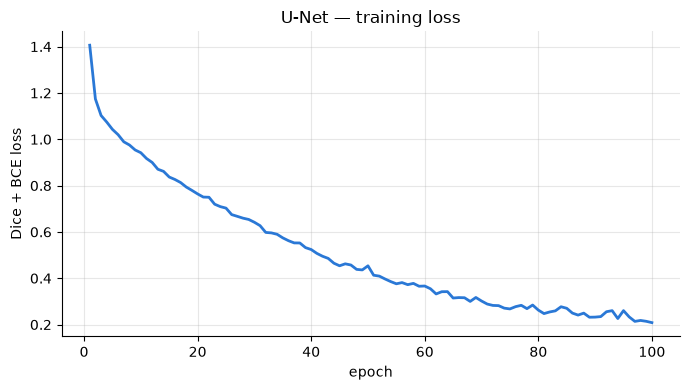

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, NUM_EPOCHS + 1), history["train_loss"], color=MODEL_COLOR, linewidth=2)
ax.set_xlabel("epoch")
ax.set_ylabel("Dice + BCE loss")
ax.set_title(f"{MODEL_LABEL} — training loss")
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_loss_curve.png"), dpi=120)
plt.show()

## 11. Predict the test set

For each test image: preprocess exactly like training (no augmentation) → sigmoid
probability at 256×256 → **bilinear upsampling of the probability map back to the
original image size** → threshold 0.5. Metrics are therefore computed at the original
resolution against the original mask. Binary masks are saved to `predictions/` with the
original filename (pixel values 0/255 so they are viewable).

In [11]:
model.eval()
pred_masks = {}
with torch.no_grad():
    for name in test_names:
        img = load_image(name)
        H, W = img.shape
        x = torch.from_numpy(preprocess_image(img))[None, None].to(device)
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=device.type == "cuda"):
            logits = model(x)
        prob = torch.sigmoid(logits.float())
        prob = F.interpolate(prob, size=(H, W), mode="bilinear", align_corners=False)[0, 0]
        pred = (prob > THRESHOLD).cpu().numpy().astype(np.uint8)
        pred_masks[name] = pred
        Image.fromarray(pred * 255).save(os.path.join(PRED_DIR, name))
print(f"saved {len(pred_masks)} predicted masks to {PRED_DIR}/")

saved 130 predicted masks to predictions/


## 12. Test-set metrics: Dice, IoU, HD95

For a predicted mask P and ground truth G (both at original resolution):

- **Dice** = 2|P∩G| / (|P| + |G|) — overlap, 0 (none) … 1 (perfect).
- **IoU** (Jaccard) = |P∩G| / |P∪G| — stricter overlap; IoU = Dice / (2 − Dice).
- **HD95** = 95th percentile of the symmetric surface distances between the boundaries of
  P and G, in **pixels** (BUSI has no physical spacing). Lower is better; it measures how
  far the predicted boundary strays, which Dice barely notices. Computed with
  `medpy.metric.binary.hd95`.

**Empty-prediction rule (same in all three notebooks):** if the model predicts no tumour
pixel at all, HD95 is undefined. We set **HD95 = diagonal of the original image**
(`sqrt(H² + W²)`, the largest distance possible in that image) and Dice = IoU = 0. We do
not drop those images (NaN), because the paired statistical tests in Task 8 need every
model to have a value for every test image. The number of empty predictions is printed.

Per-image results are written to `per_image_metrics.csv` (columns `image_name, dice, iou,
hd95`) in the `test.xlsx` order, which is identical for all three models.

In [12]:
def segmentation_metrics(pred, gt):
    """Return (dice, iou, hd95, is_empty) for binary masks of the same shape."""
    pred, gt = pred.astype(bool), gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    dice = 2.0 * inter / (pred.sum() + gt.sum())
    iou = inter / union
    if pred.sum() == 0:                       # empty prediction -> worst-case HD95
        return 0.0, 0.0, float(np.hypot(*gt.shape)), True
    return float(dice), float(iou), float(medpy_binary.hd95(pred, gt)), False


rows, n_empty_pred = [], 0
for name in test_names:
    d, j, h, empty = segmentation_metrics(pred_masks[name], load_mask(name))
    n_empty_pred += empty
    rows.append({"image_name": name, "dice": d, "iou": j, "hd95": h})
metrics_df = pd.DataFrame(rows, columns=["image_name", "dice", "iou", "hd95"])
metrics_df.to_csv(METRICS_CSV, index=False)

summary = {m: {"mean": float(metrics_df[m].mean()), "std": float(metrics_df[m].std(ddof=1))}
           for m in ["dice", "iou", "hd95"]}
summary["n_test"] = len(metrics_df)
summary["n_empty_predictions"] = int(n_empty_pred)
with open(os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_test_metrics.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(f"{MODEL_LABEL} on {len(metrics_df)} test images (mean ± sample std):")
for m in ["dice", "iou", "hd95"]:
    print(f"  {m:5s} {summary[m]['mean']:.4f} ± {summary[m]['std']:.4f}")
print(f"  empty predictions: {n_empty_pred} / {len(metrics_df)} (HD95 set to image diagonal)")
print(f"per-image metrics -> {METRICS_CSV}")

U-Net on 130 test images (mean ± sample std):
  dice  0.7301 ± 0.3108
  iou   0.6491 ± 0.3093
  hd95  104.0052 ± 162.8848
  empty predictions: 5 / 130 (HD95 set to image diagonal)
per-image metrics -> per_image_metrics.csv


## 13. Per-image visual check of every test image

One row per test image, in `test.xlsx` order: original image, ground-truth mask, predicted
mask, and an overlay (ground-truth contour in yellow, prediction filled and outlined in
this model's colour). The row title gives that image's Dice / IoU / HD95. Images are
shown 10 per figure.

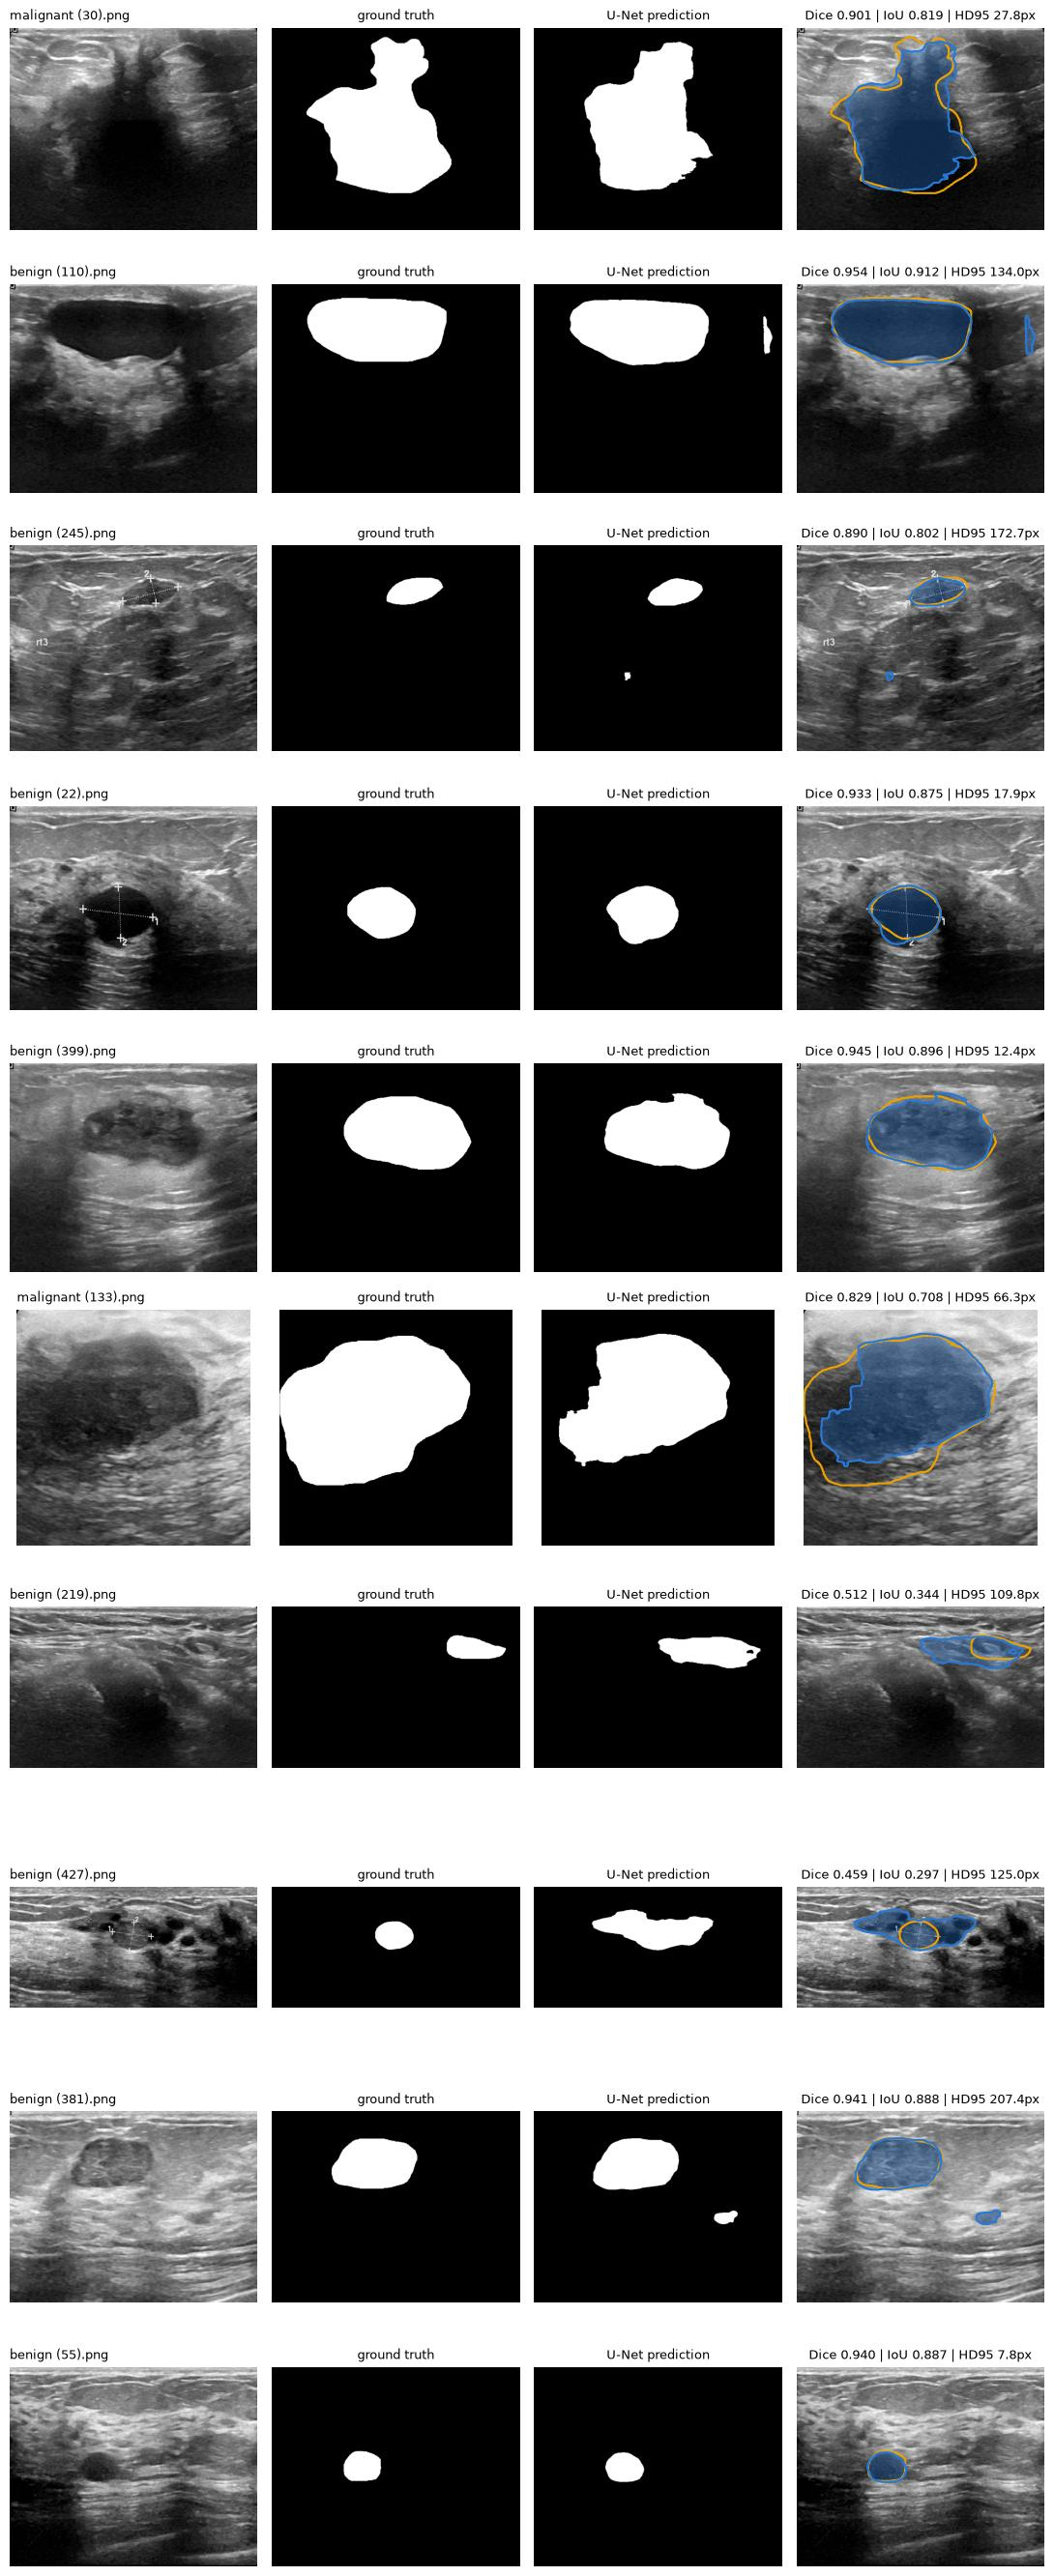

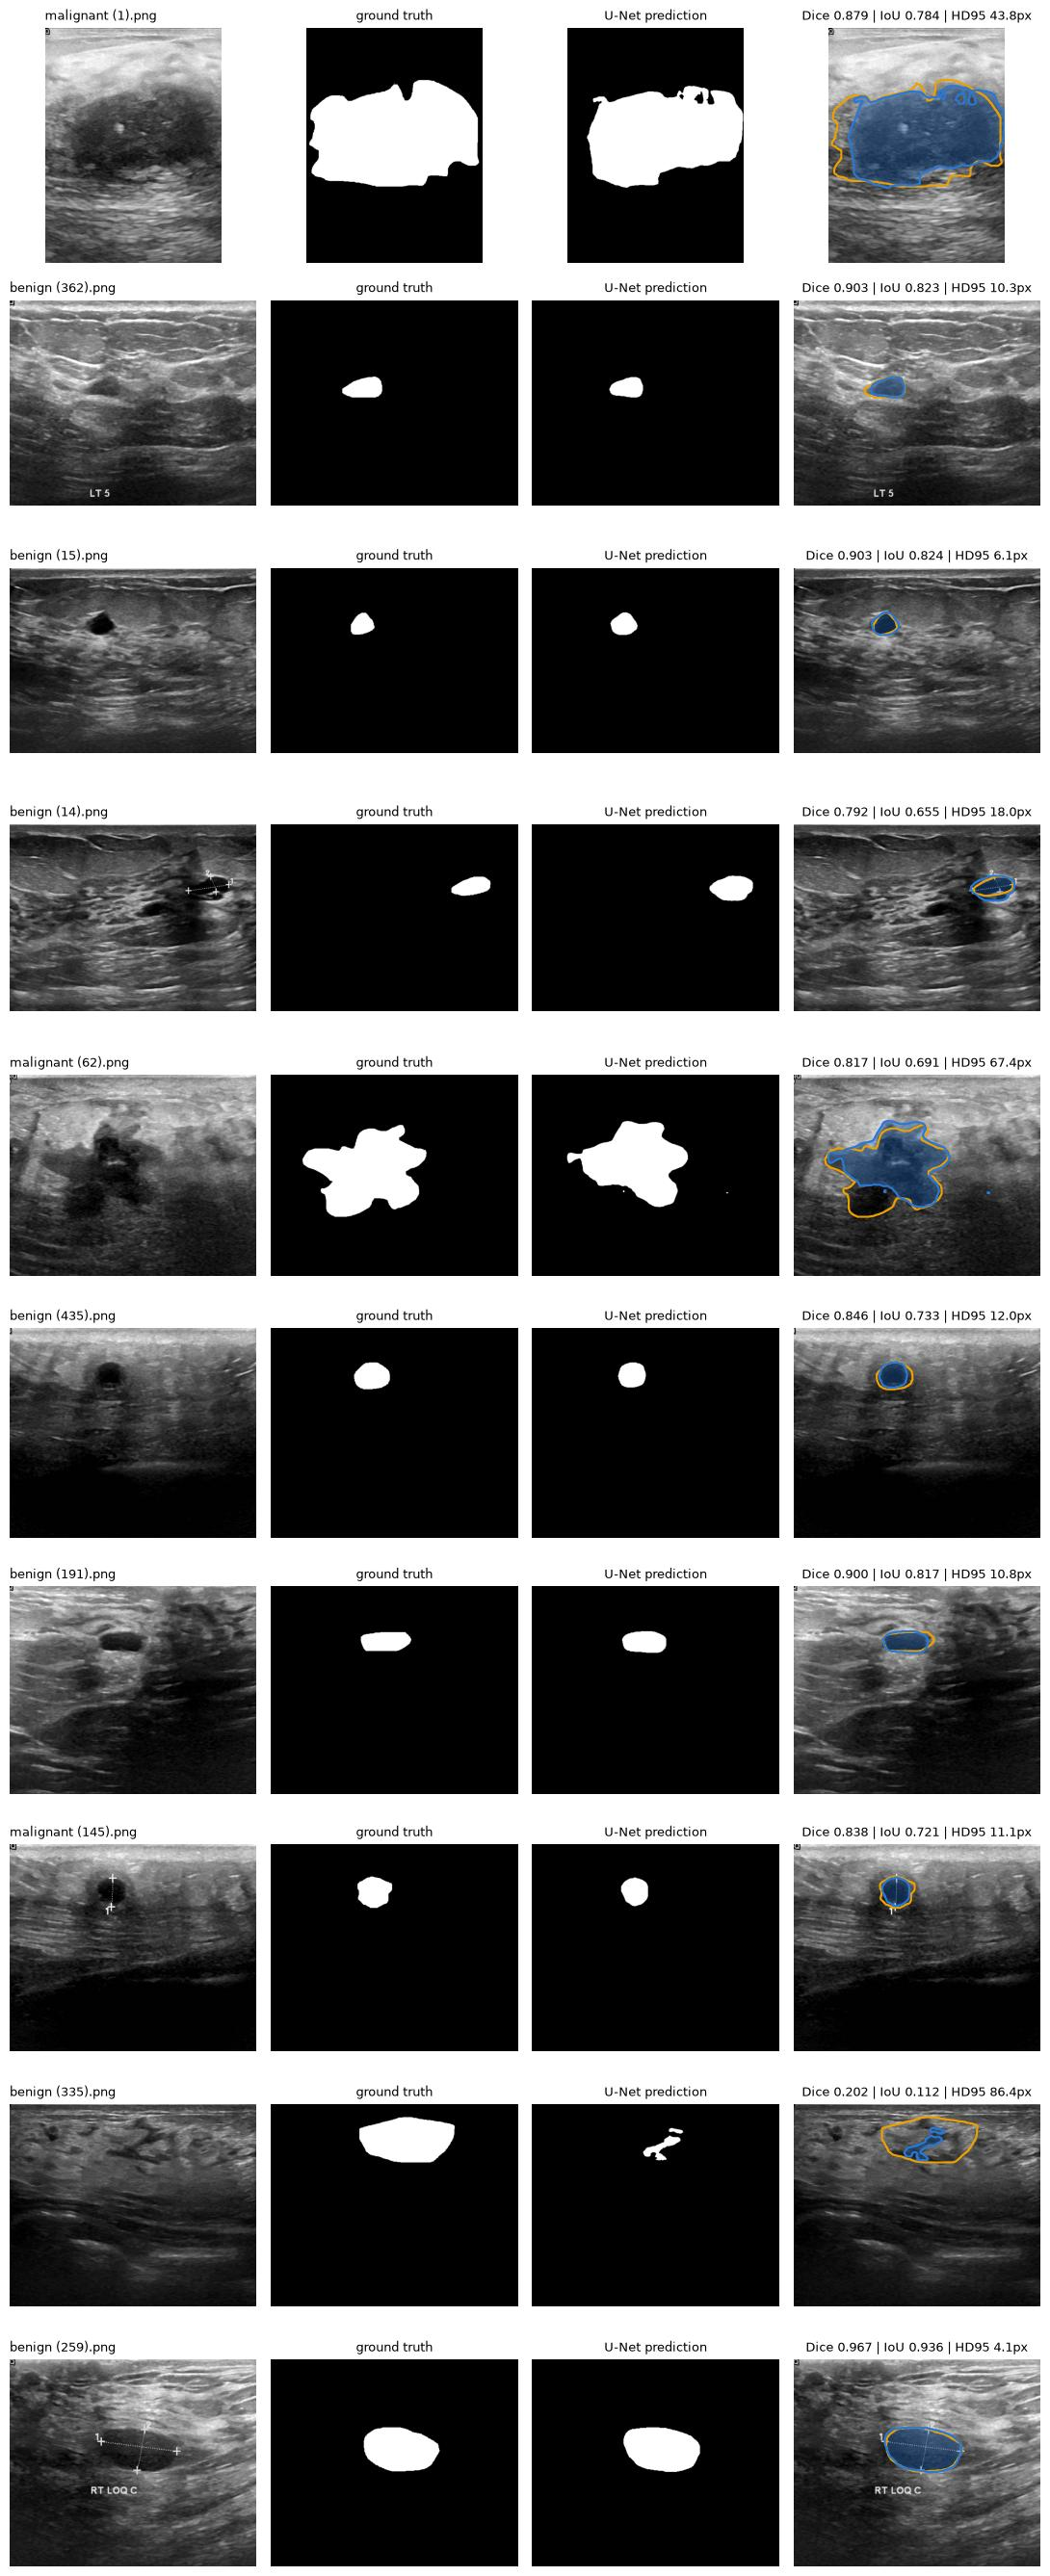

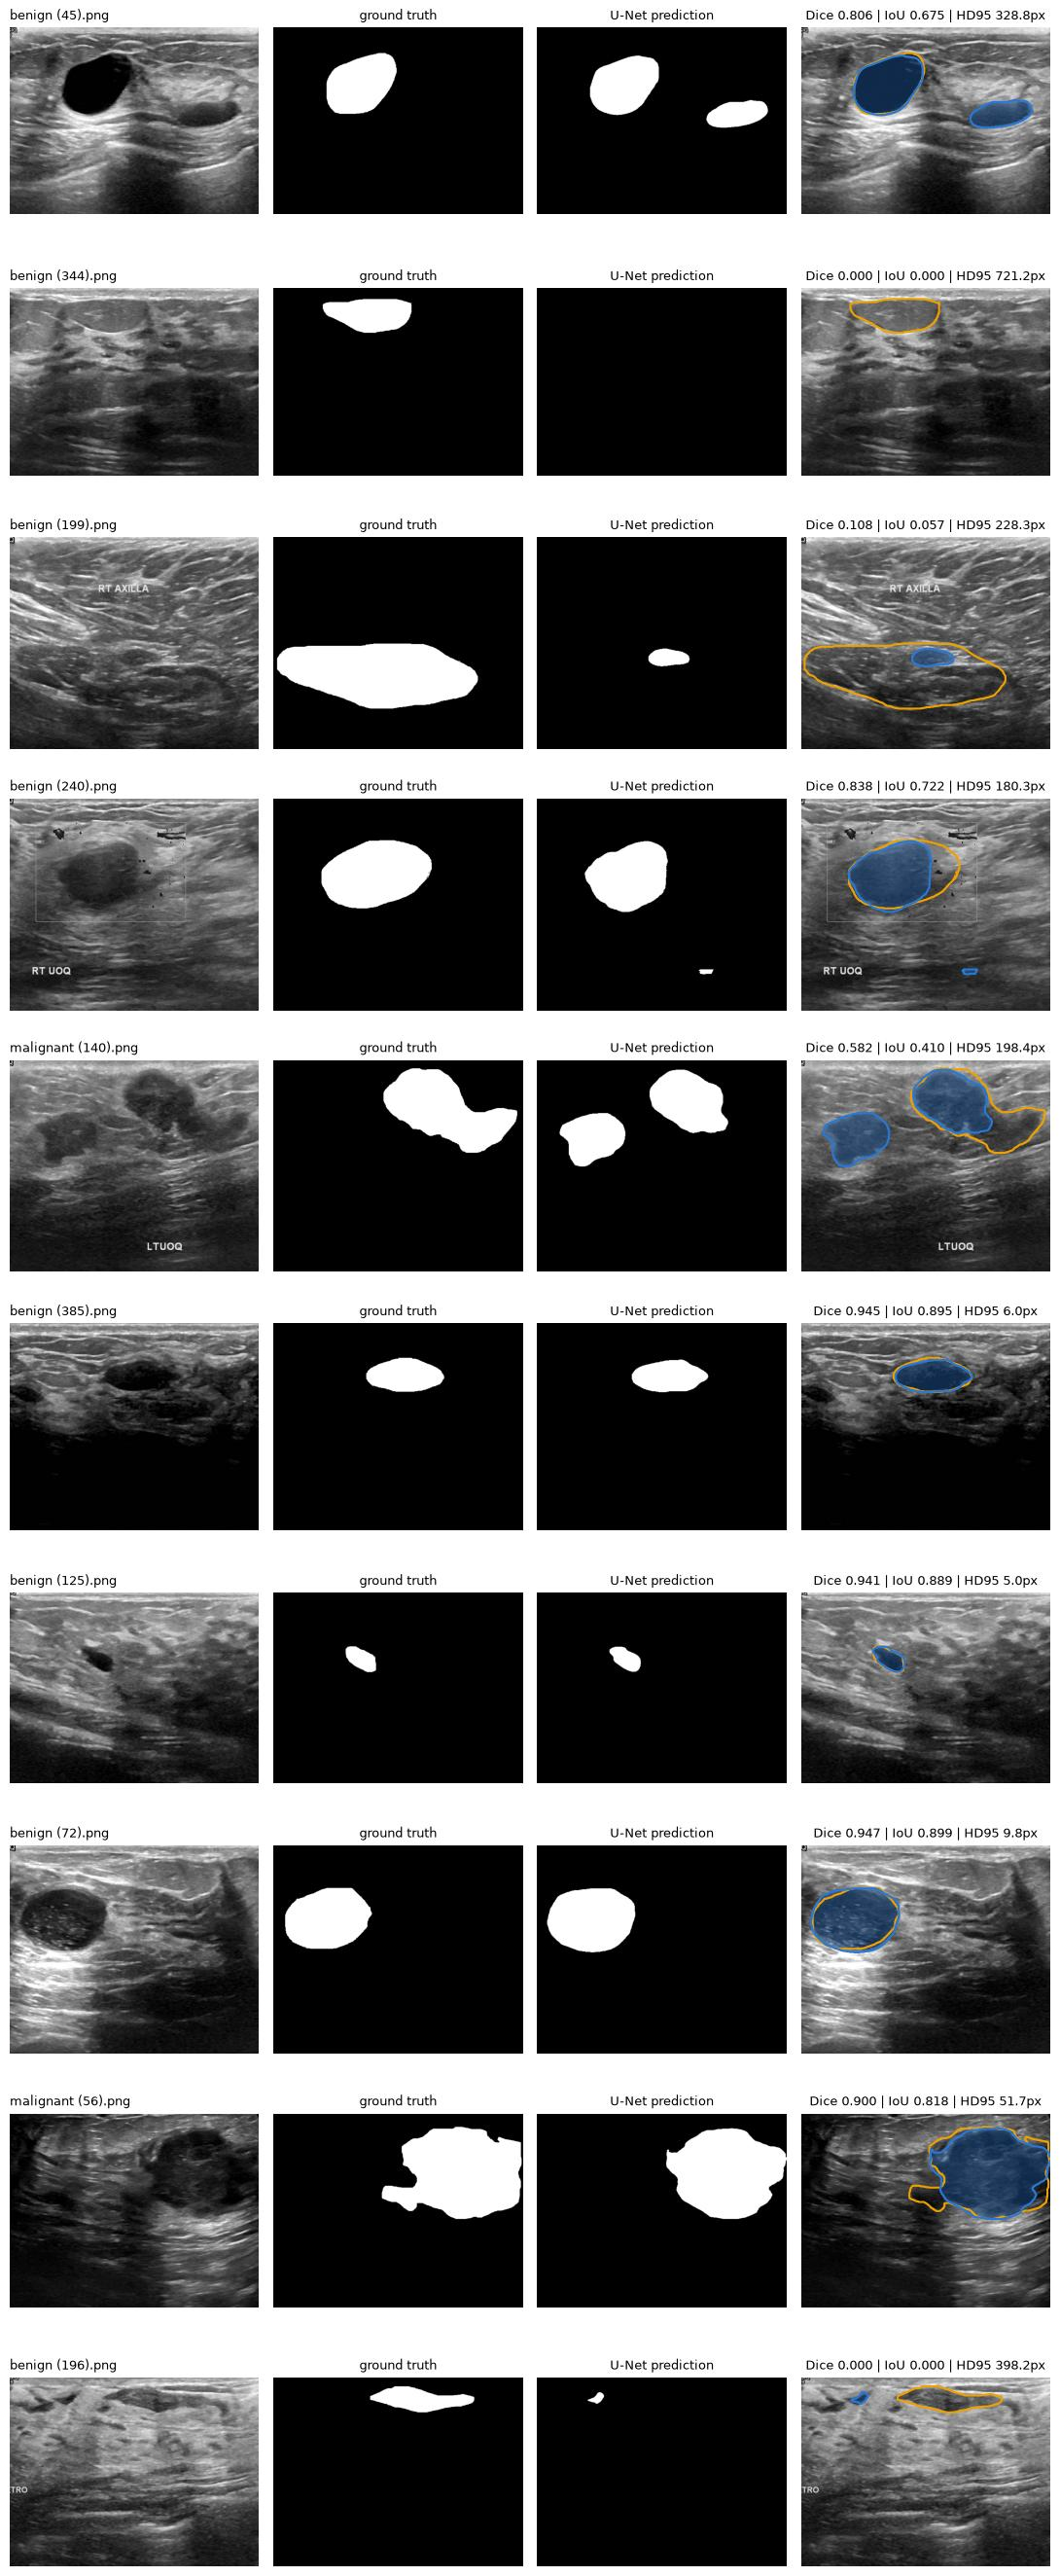

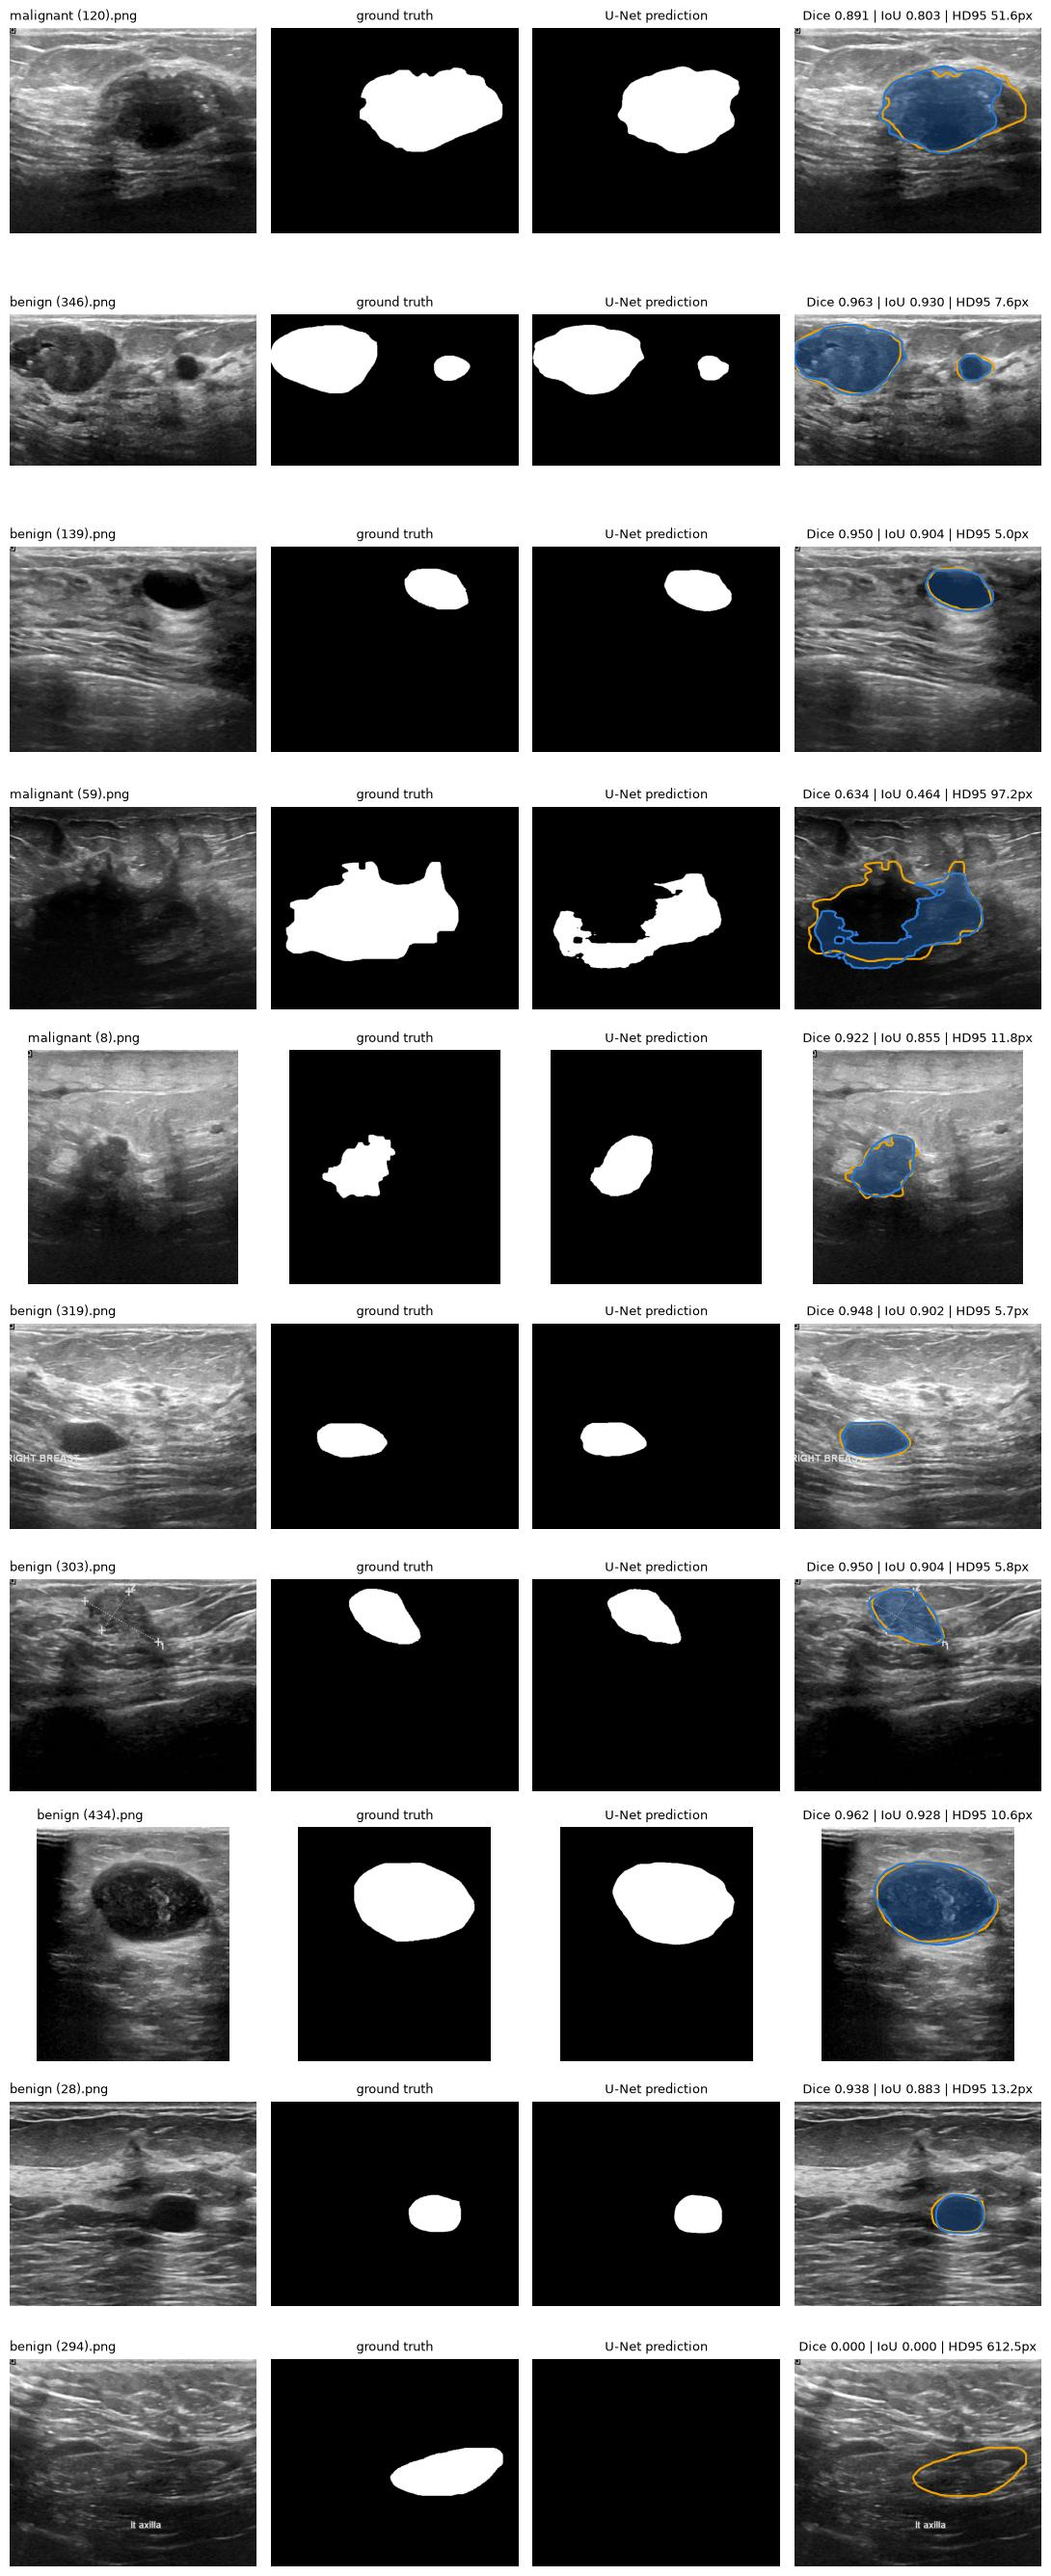

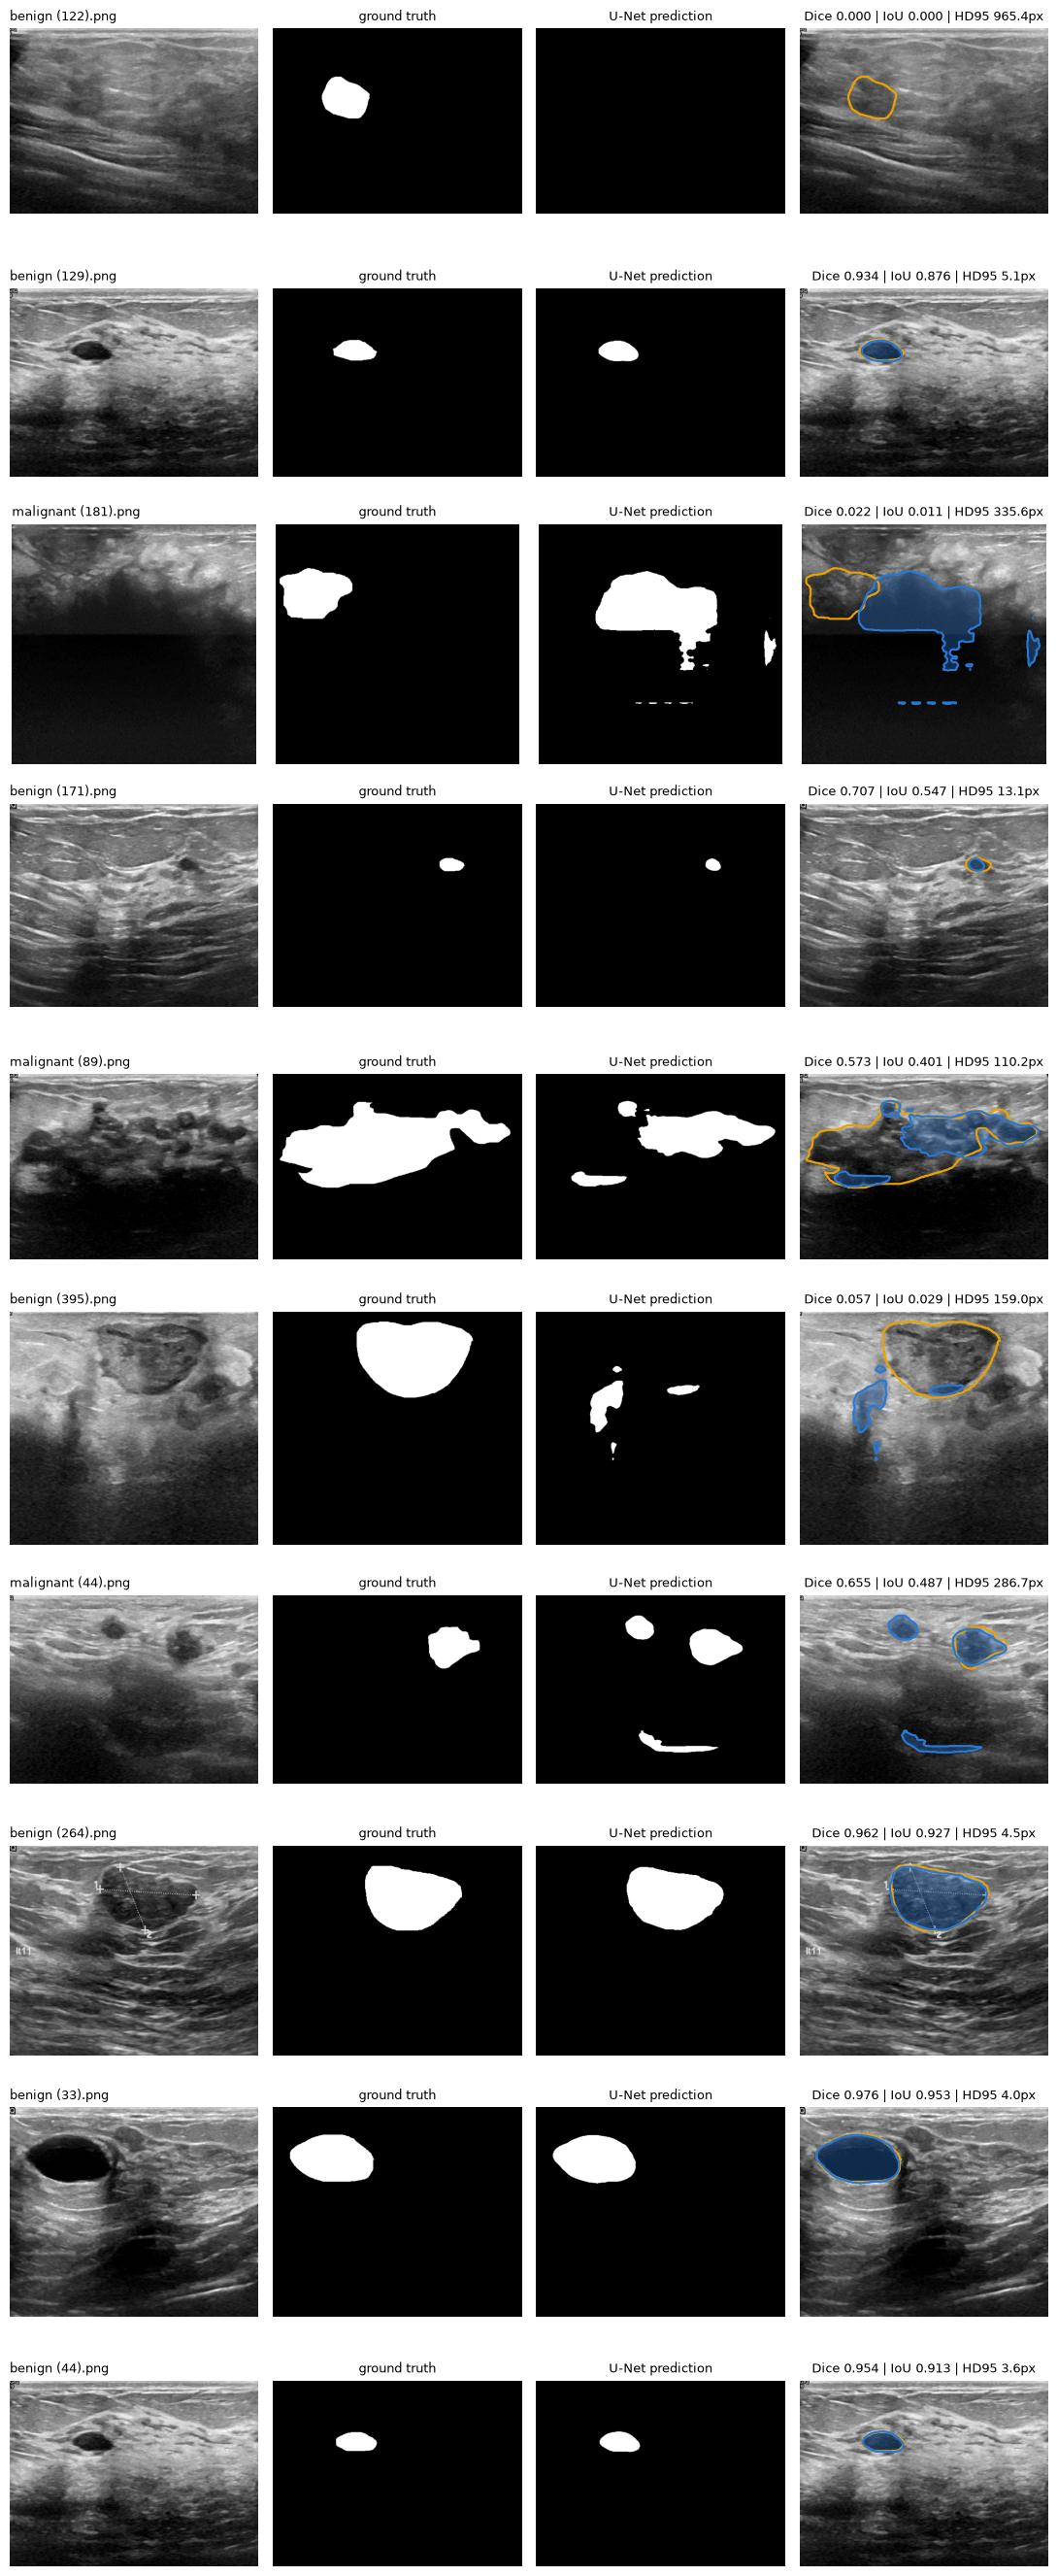

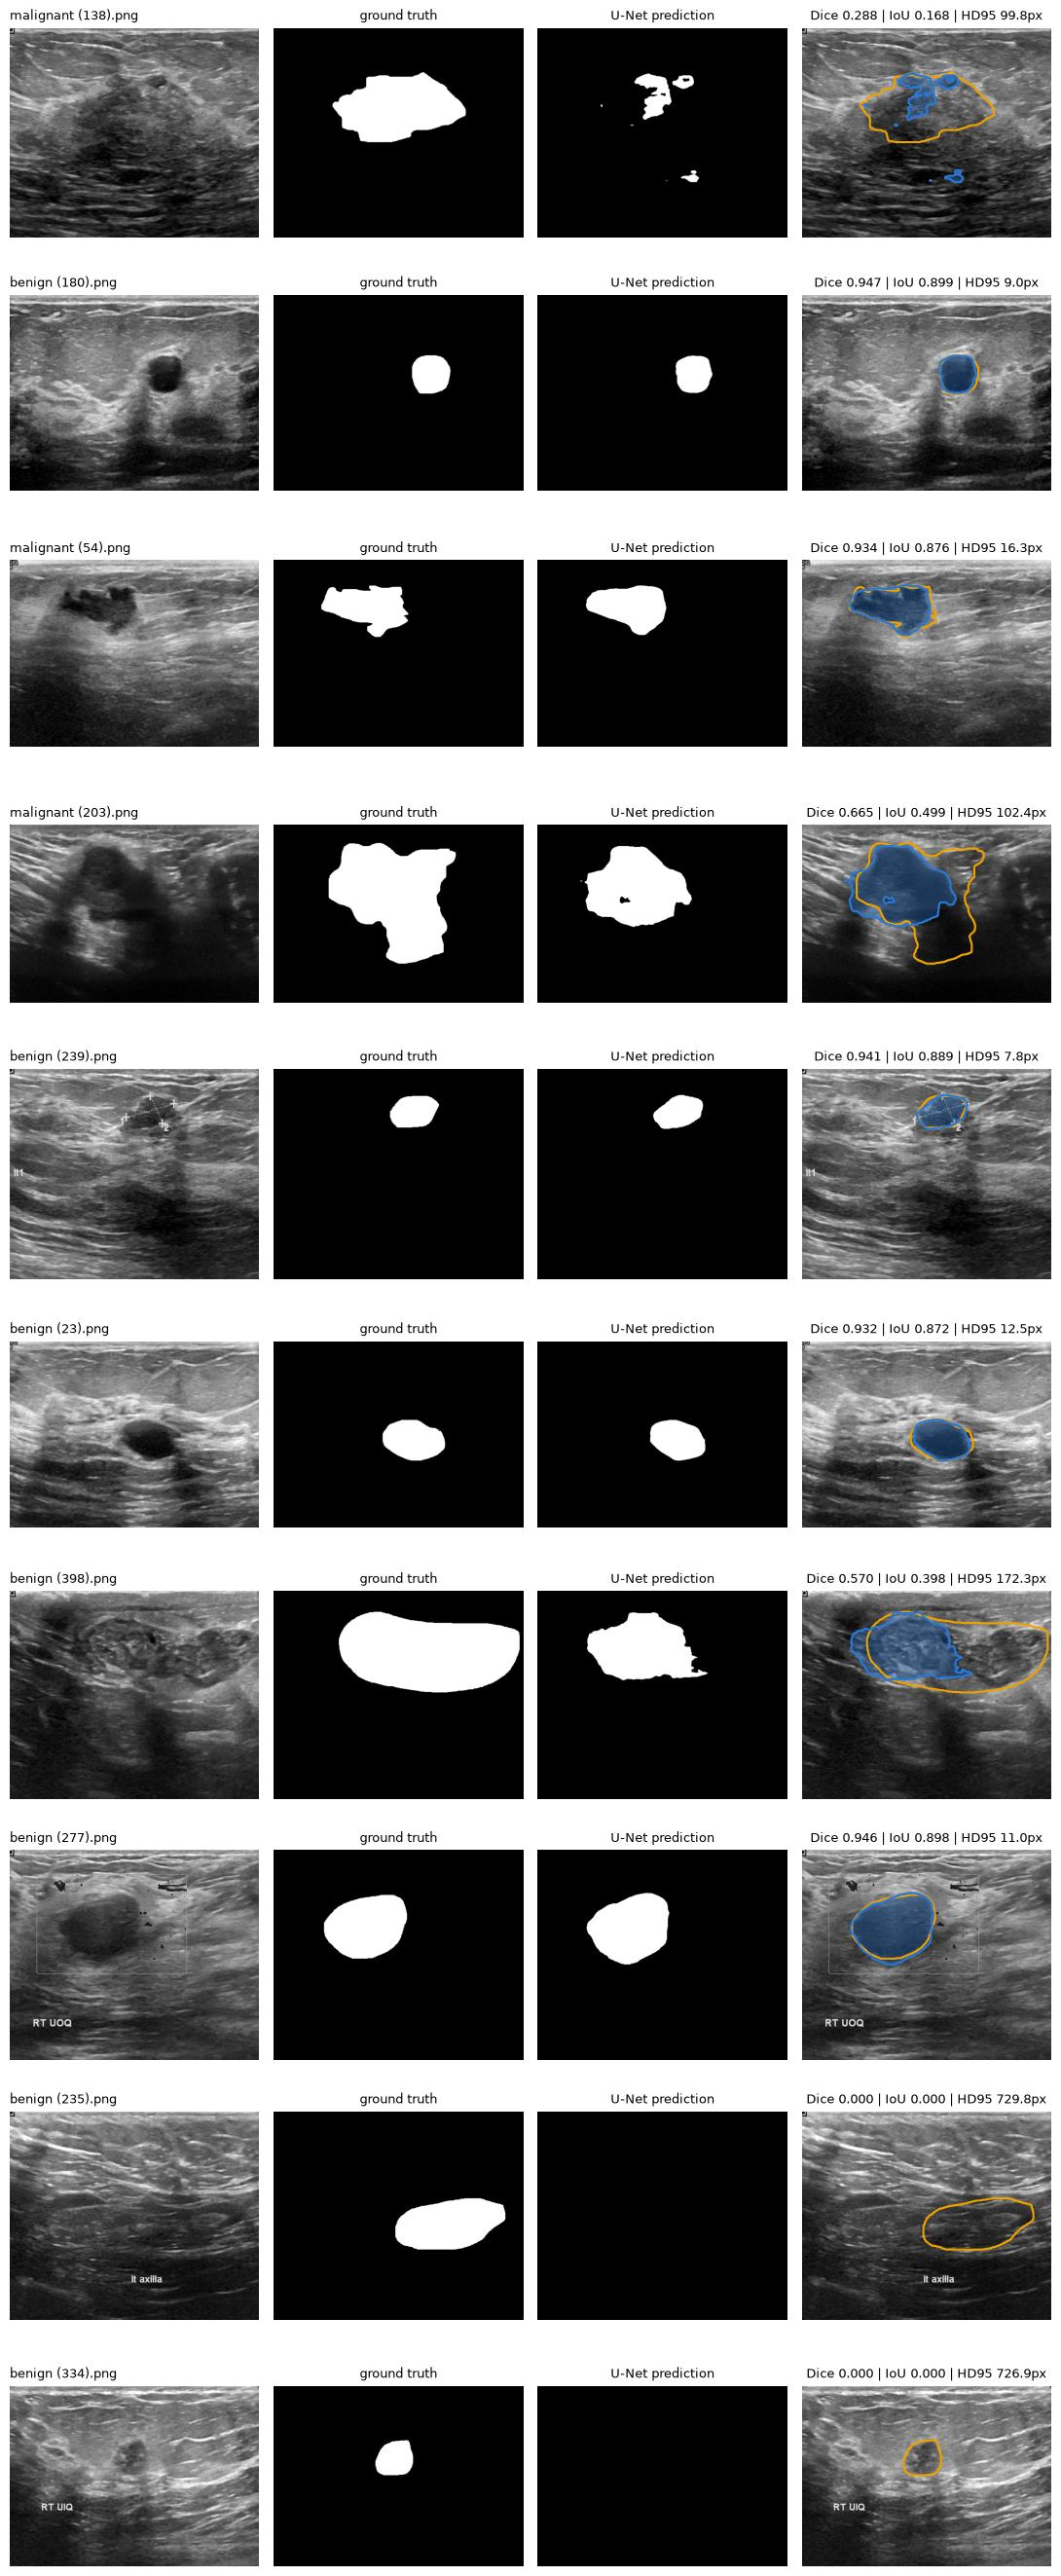

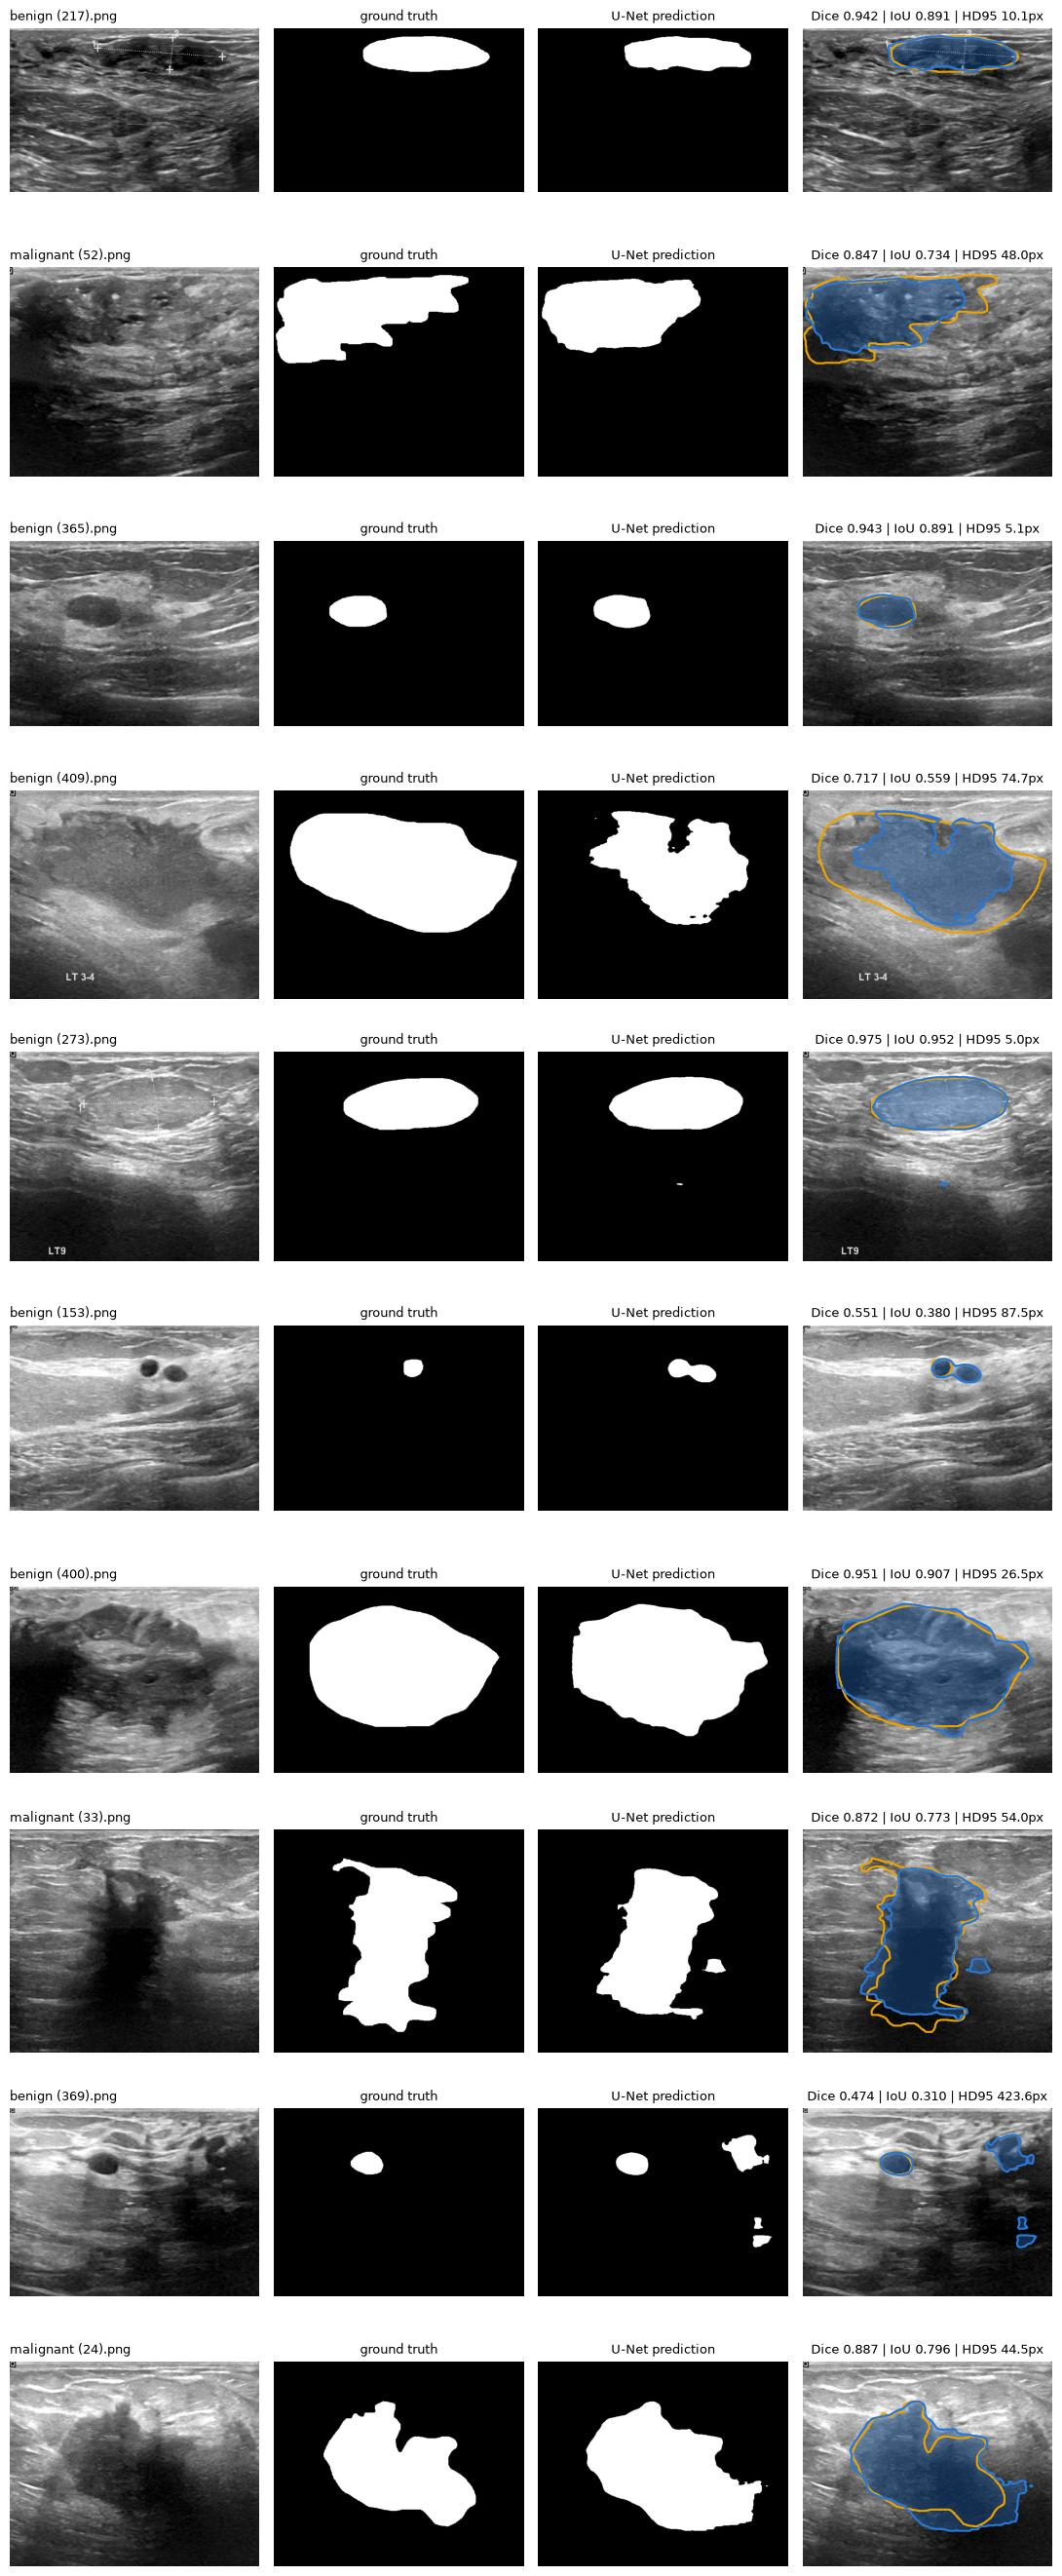

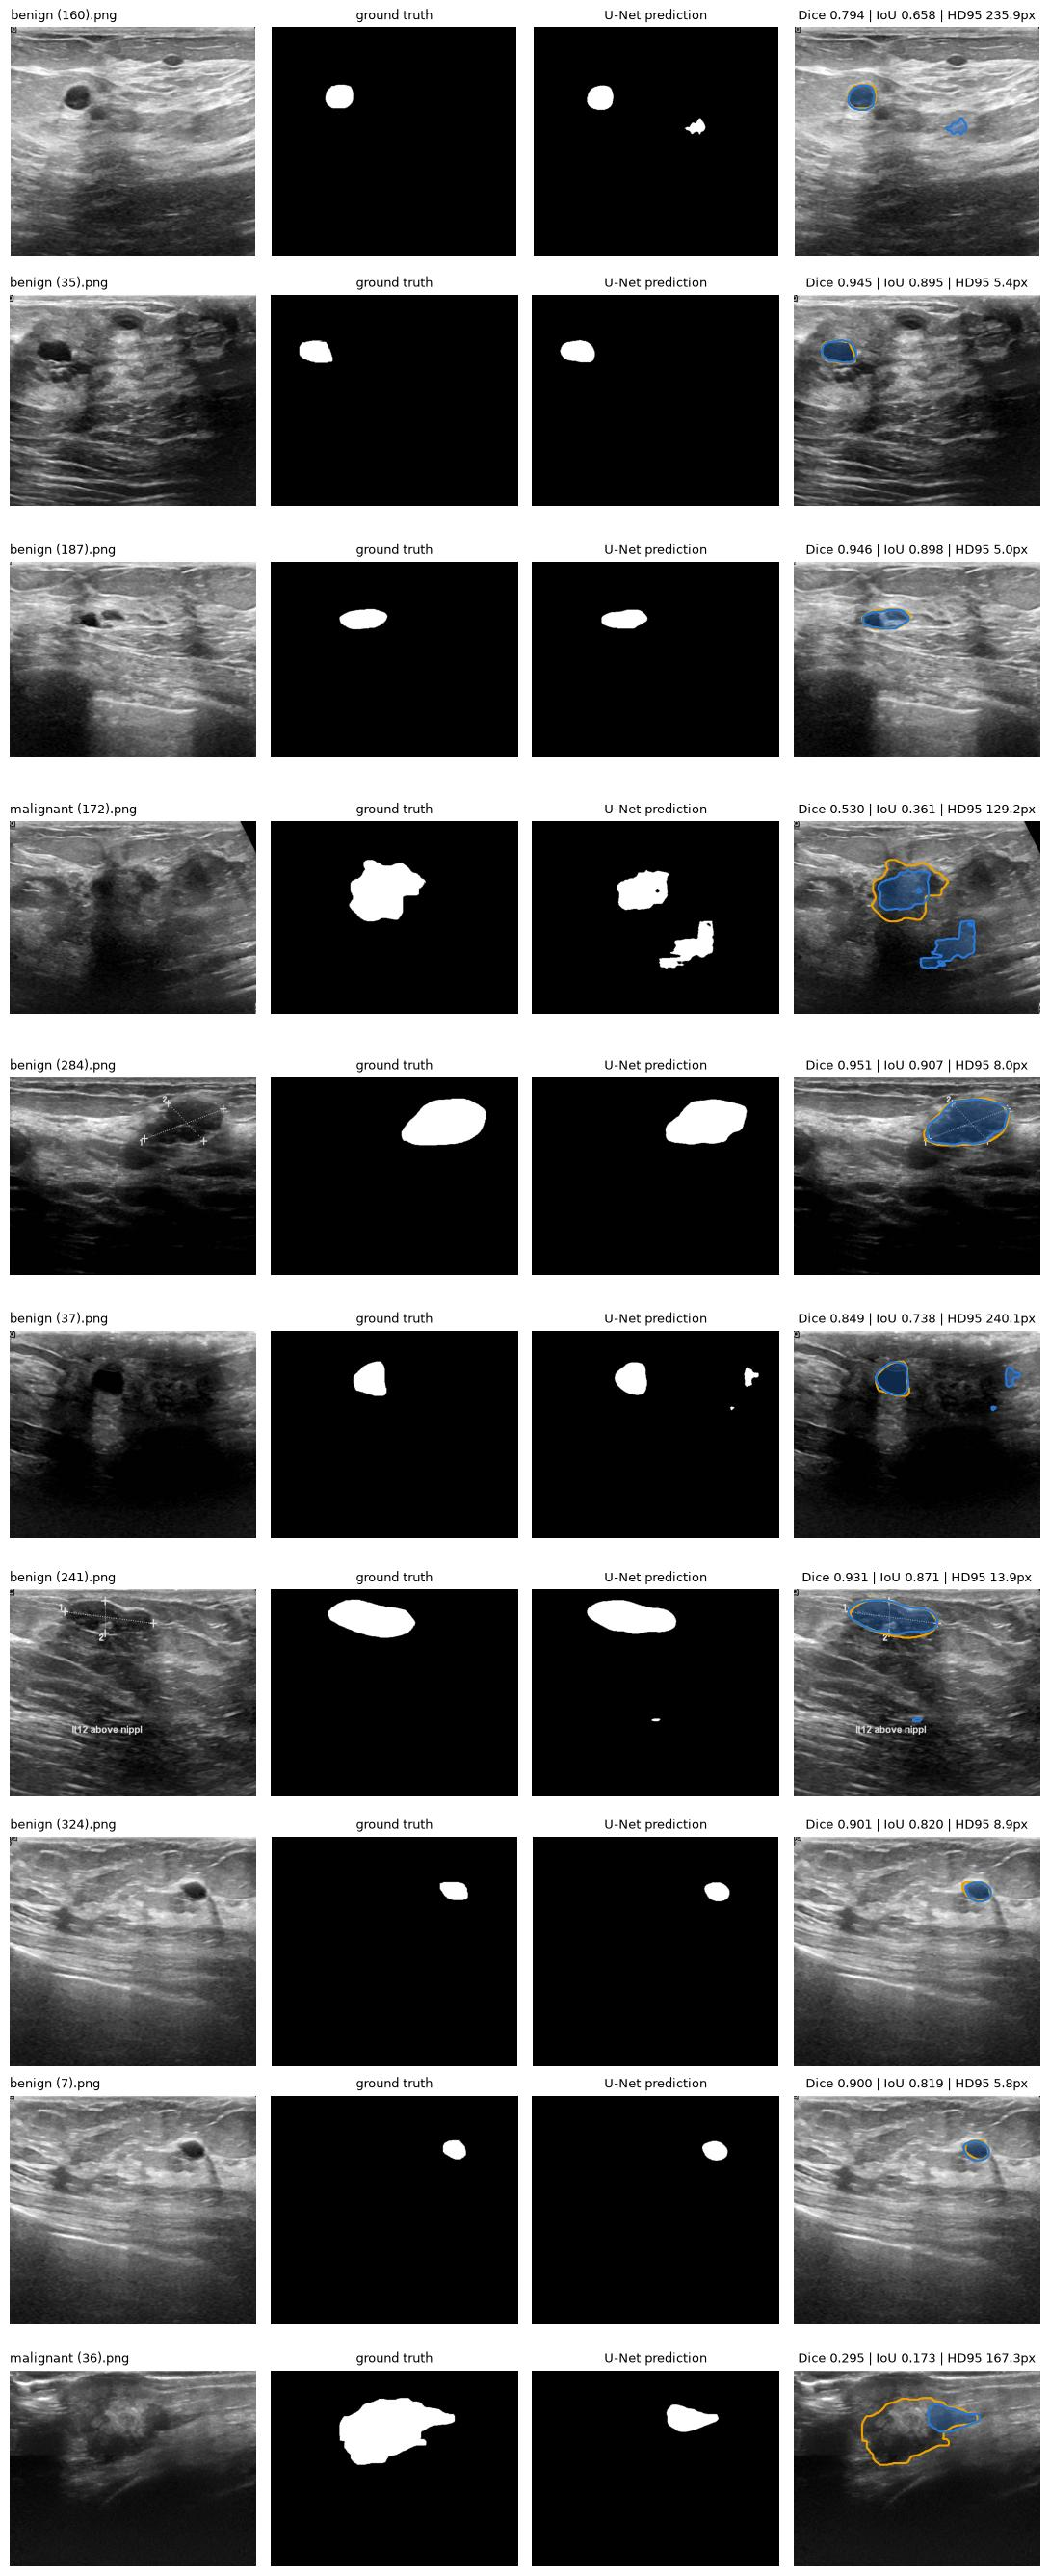

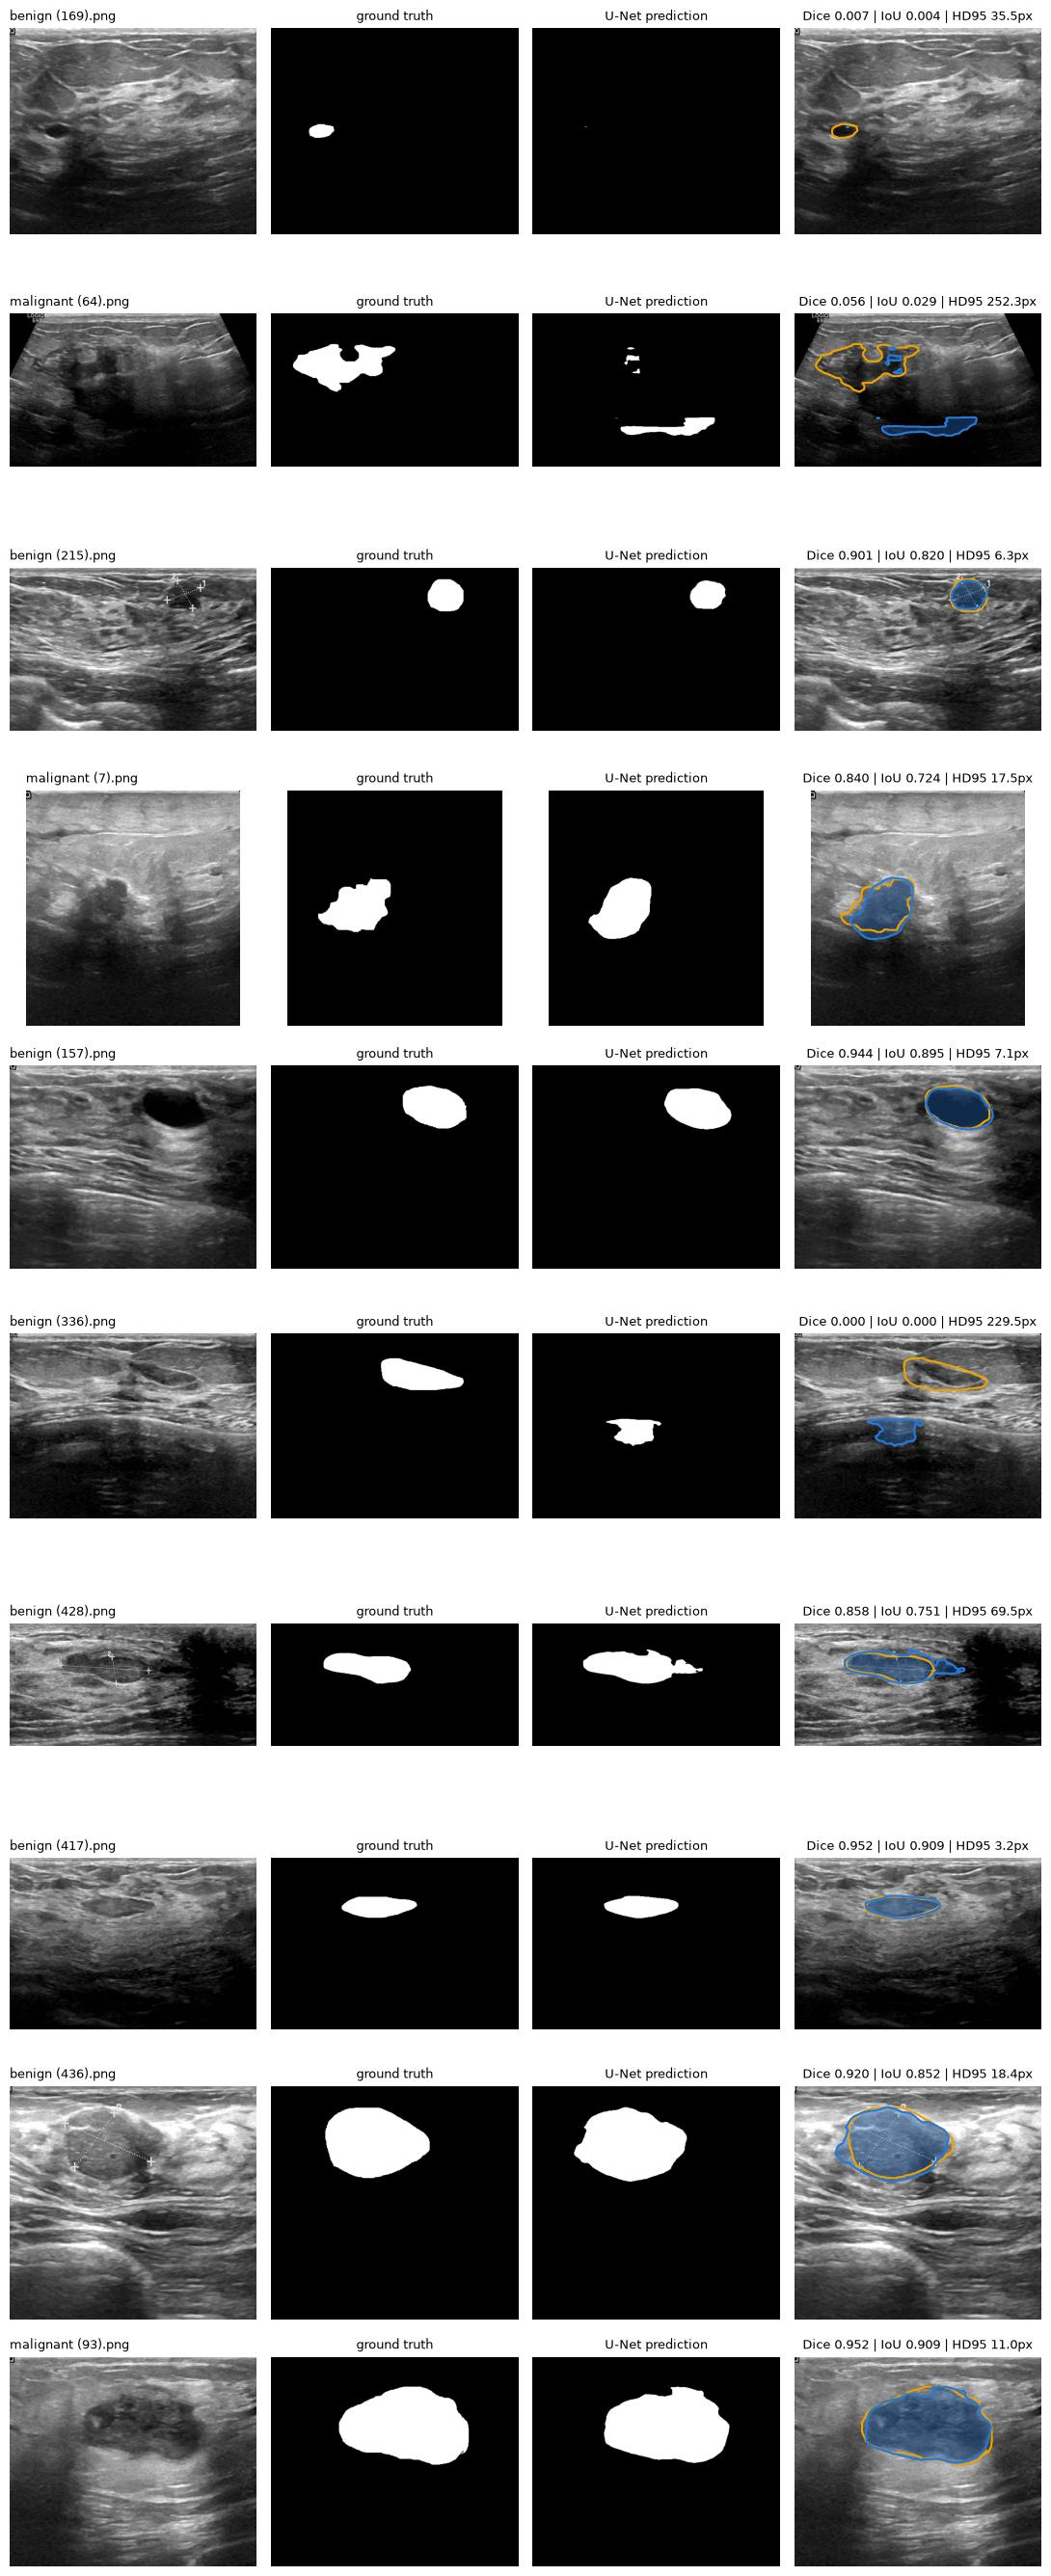

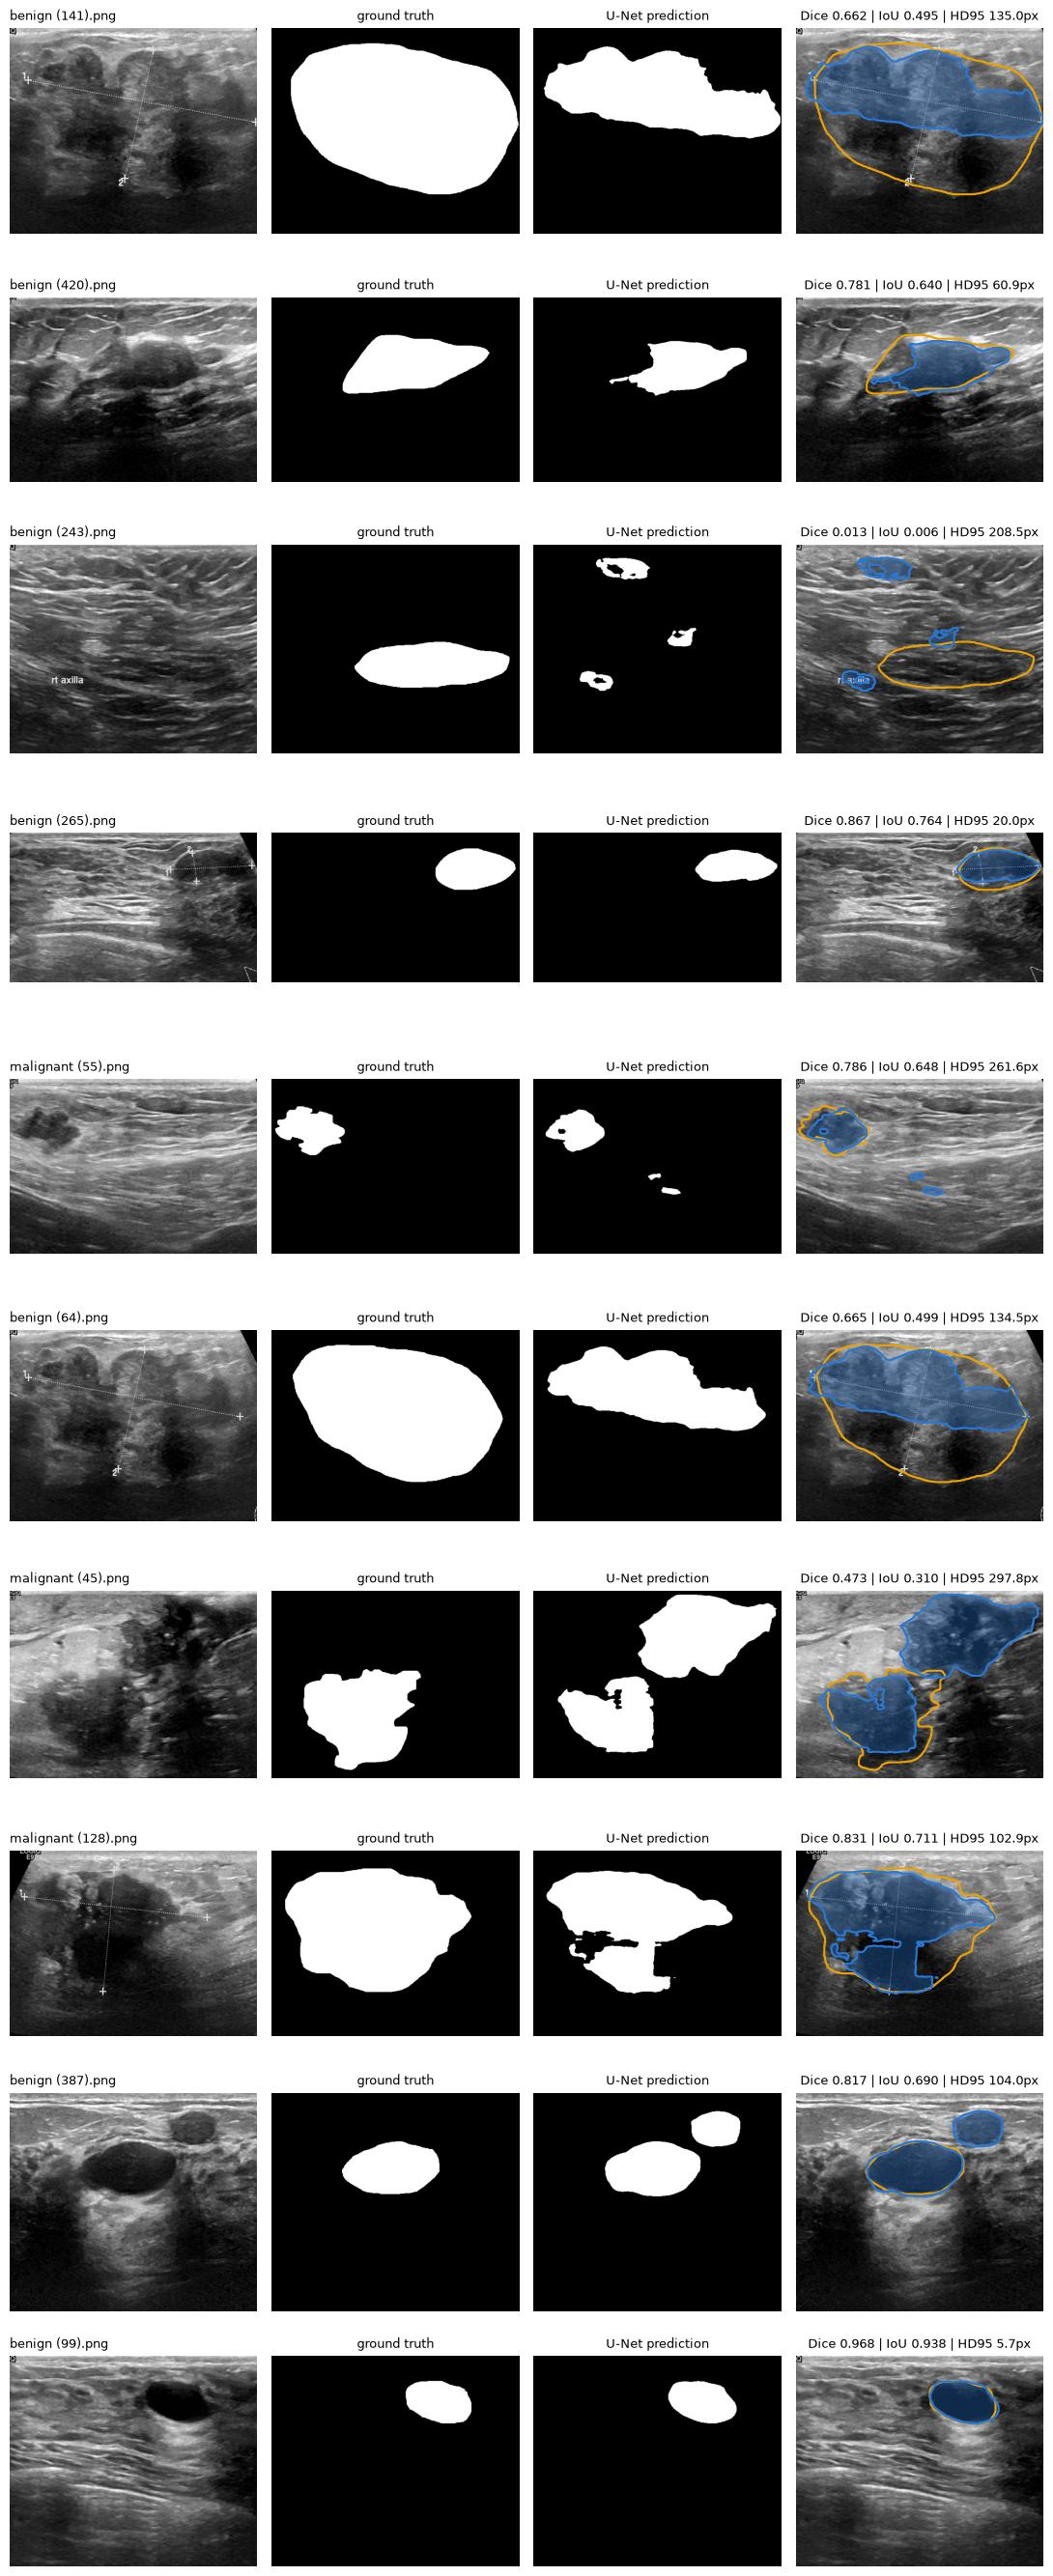

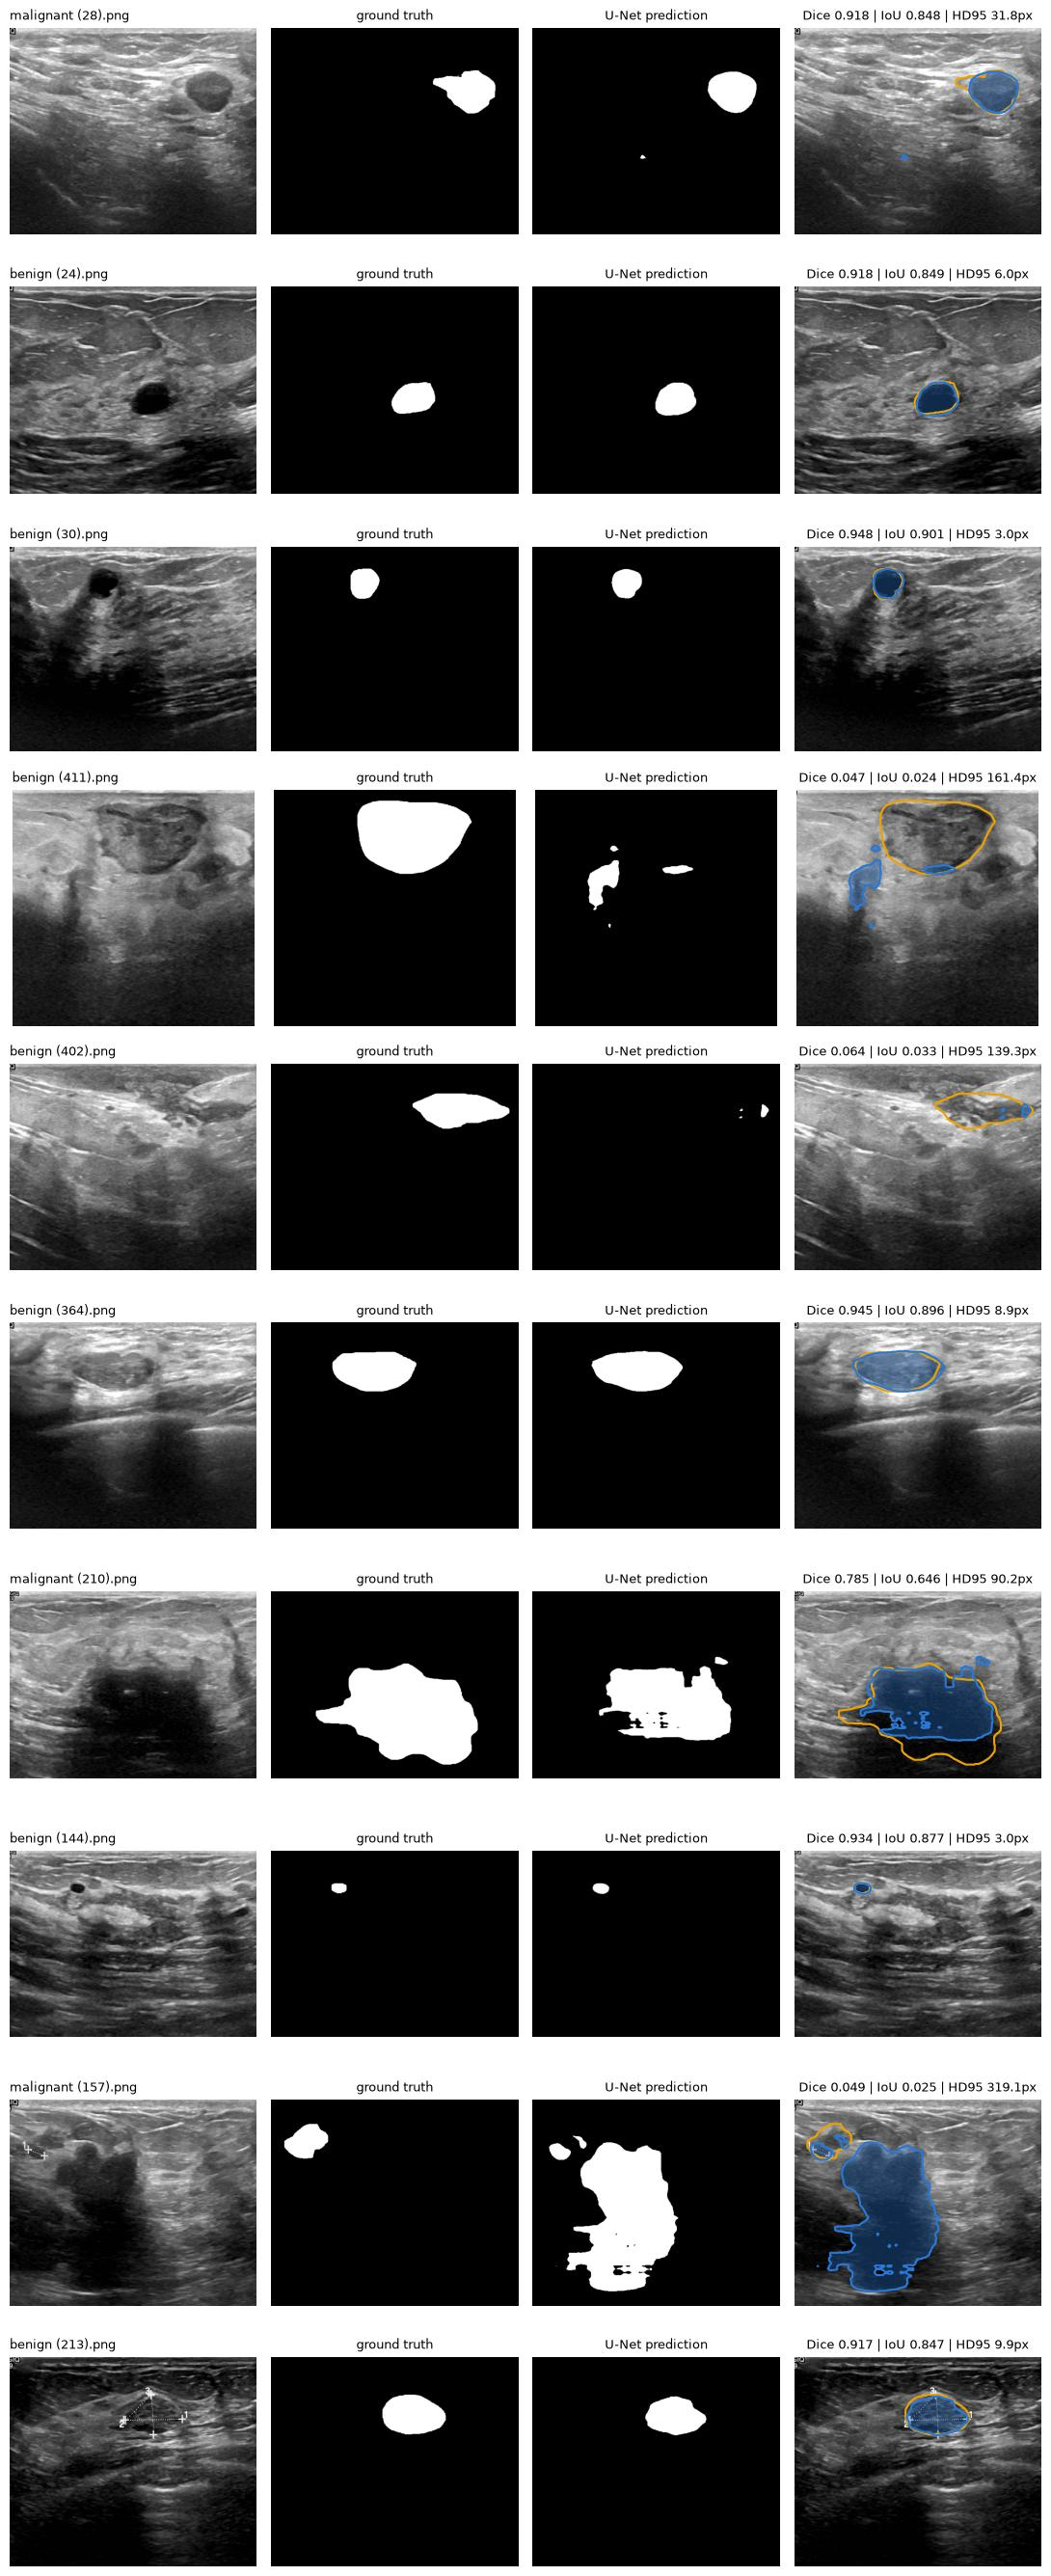

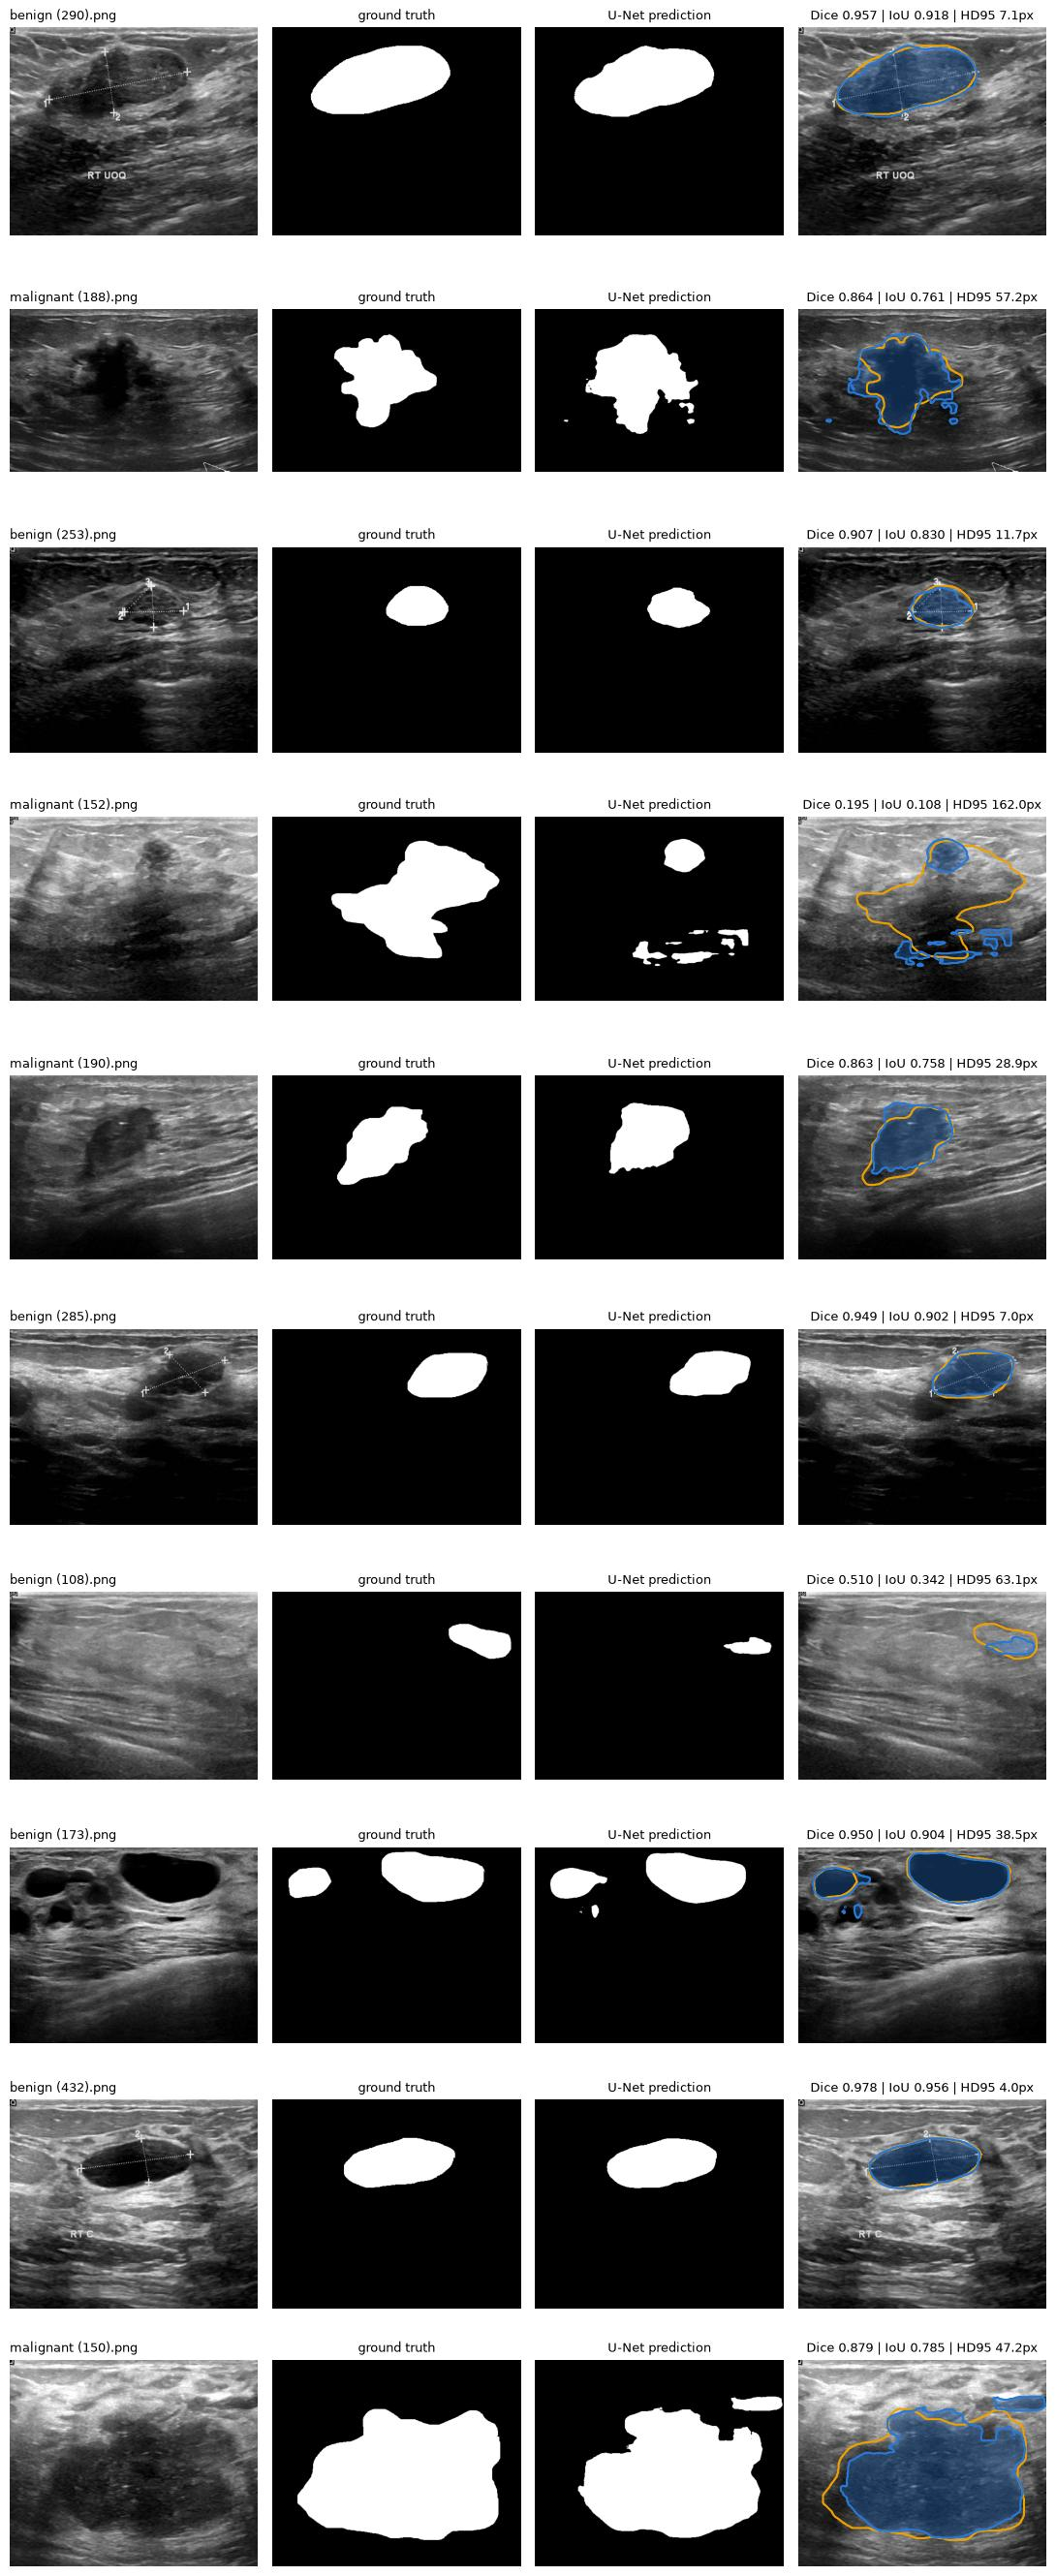

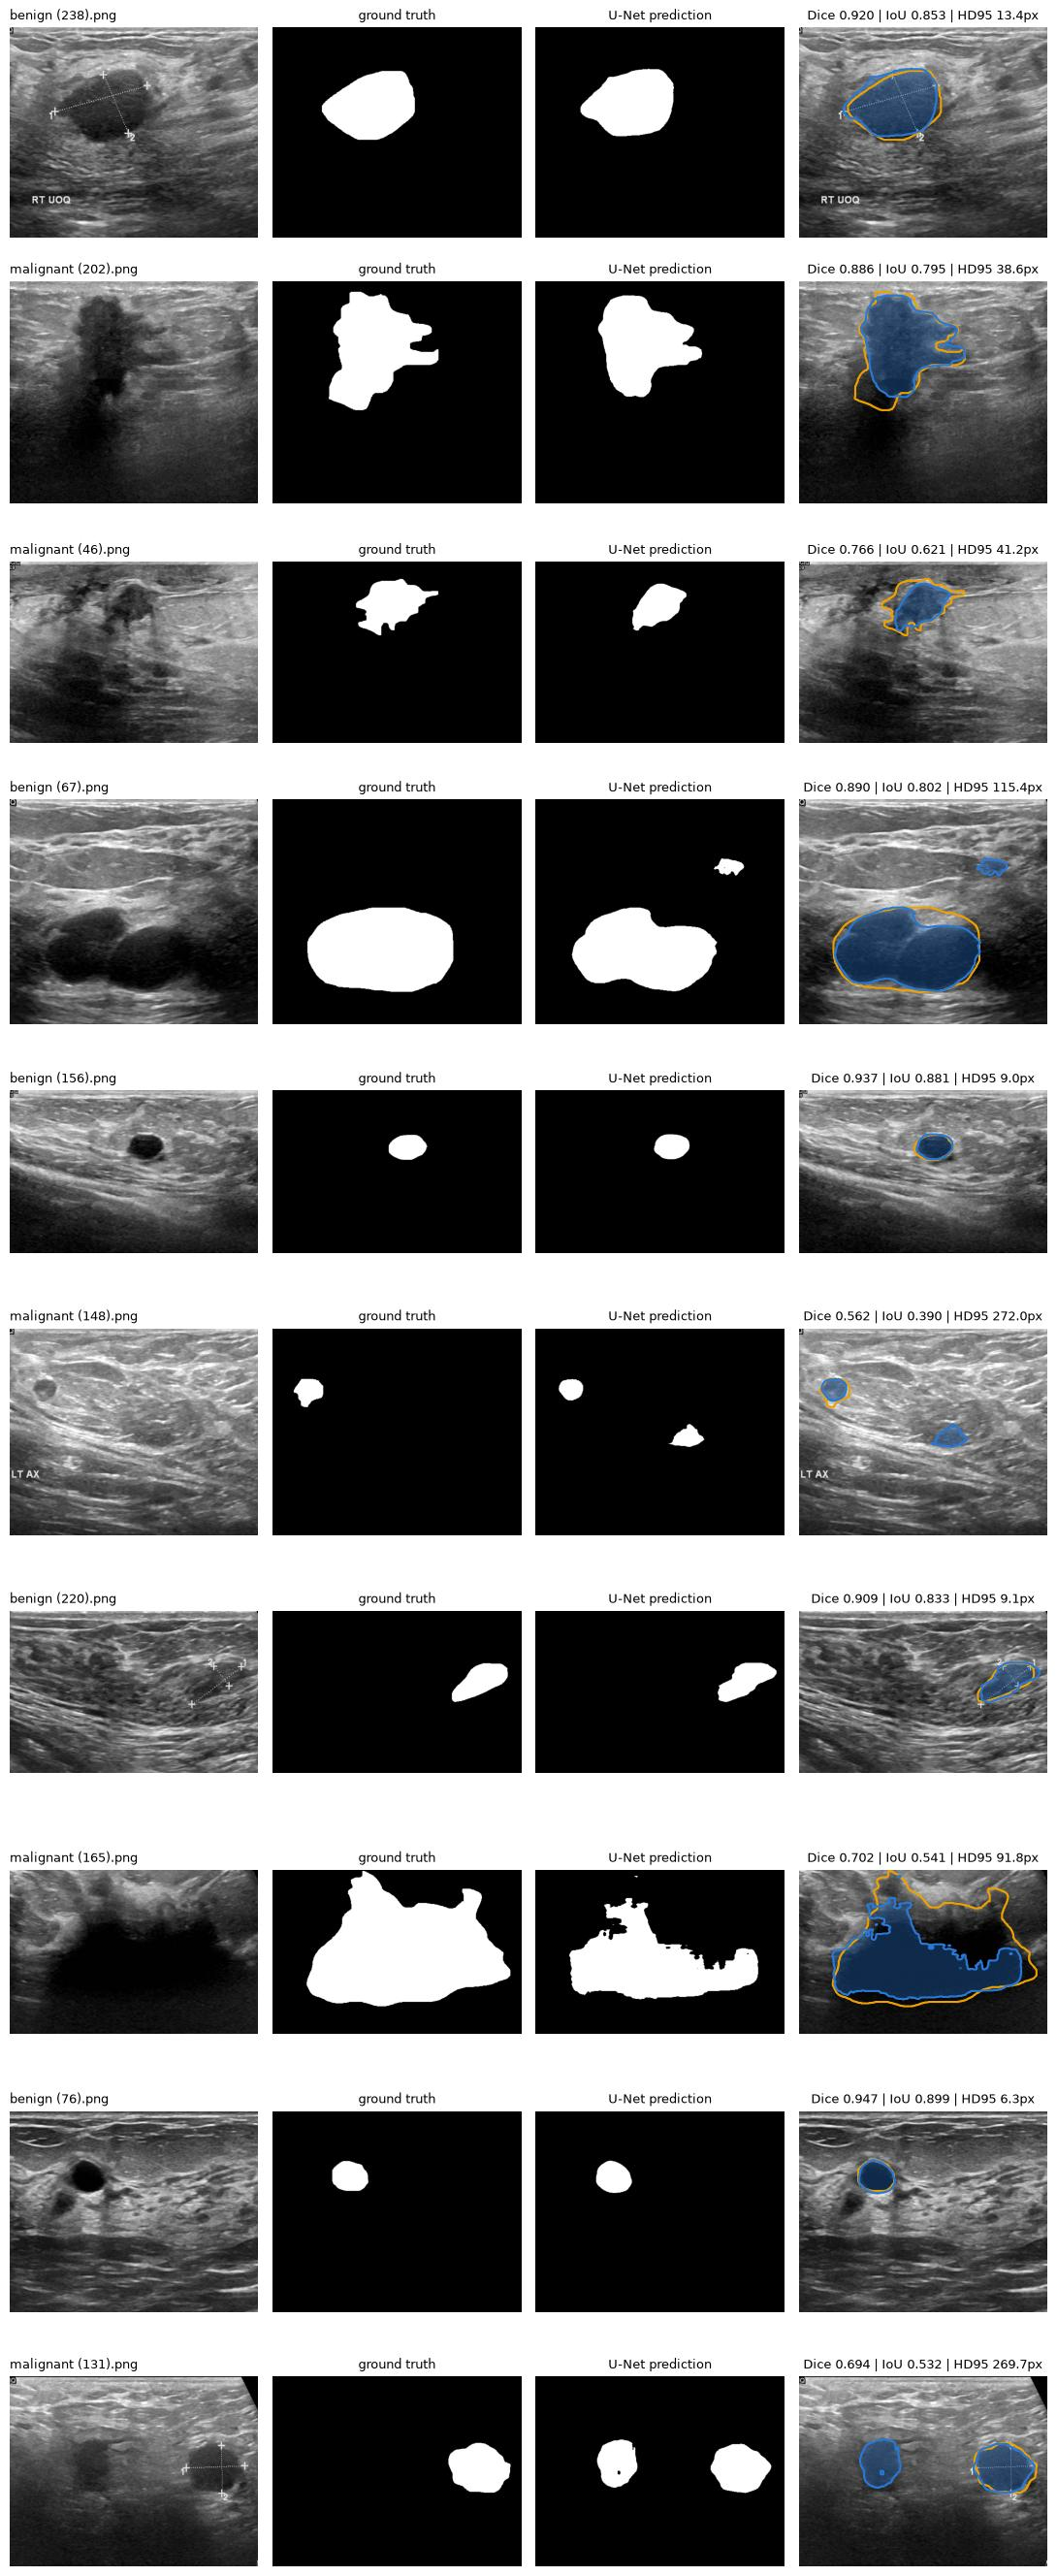

In [13]:
from matplotlib_inline.backend_inline import set_matplotlib_formats

GT_COLOR = "#eda100"   # ground-truth contour colour, the same in every notebook
# 130 rows of photos: embed as JPEG instead of PNG to keep the executed notebook small
set_matplotlib_formats("jpeg")


def show_page(names):
    fig, axes = plt.subplots(len(names), 4, figsize=(11, 2.7 * len(names)))
    axes = np.atleast_2d(axes)
    for r, name in enumerate(names):
        img, gt, pred = load_image(name), load_mask(name), pred_masks[name]
        row = metrics_df.set_index("image_name").loc[name]
        axes[r, 0].imshow(img, cmap="gray")
        axes[r, 0].set_title(f"{name}", fontsize=9, loc="left")
        axes[r, 1].imshow(gt, cmap="gray", vmin=0, vmax=1)
        axes[r, 1].set_title("ground truth", fontsize=9)
        axes[r, 2].imshow(pred, cmap="gray", vmin=0, vmax=1)
        axes[r, 2].set_title(f"{MODEL_LABEL} prediction", fontsize=9)
        axes[r, 3].imshow(img, cmap="gray")
        axes[r, 3].imshow(np.ma.masked_where(pred == 0, pred), cmap=ListedColormap([MODEL_COLOR]),
                          alpha=0.35, vmin=0, vmax=1)
        axes[r, 3].contour(gt, levels=[0.5], colors=GT_COLOR, linewidths=1.5)
        if pred.any():
            axes[r, 3].contour(pred, levels=[0.5], colors=MODEL_COLOR, linewidths=1.5)
        axes[r, 3].set_title(f"Dice {row.dice:.3f} | IoU {row.iou:.3f} | HD95 {row.hd95:.1f}px",
                             fontsize=9)
        for ax in axes[r]:
            ax.axis("off")
    fig.tight_layout()
    plt.show()


for start in range(0, len(test_names), 10):
    show_page(test_names[start:start + 10])